---
title: Ekstraksi Fitur Menggunakan TSFEL
---

## Pendahuluan

### Review Tugas 2

#### Mengapa Perlu Melakukan Review Tugas 2?


Pengerjaan Tugas 3 merupakan kelanjutan langsung (*continuity*) dari hasil yang telah diperoleh pada Tugas 2. Dalam kerangka kerja **CRISP-DM (*Cross-Industry Standard Process for Data Mining*)**, alur kerja data science bergerak secara iteratif dari fase pemahaman data (*Data Understanding*) dan penyiapan data (*Data Preparation*) menuju fase pemodelan (*Modeling*). Tugas 2 telah berhasil memigrasikan dataset ke infrastruktur *cloud database* dan menghasilkan profil statistik deskriptif dari data kualitas udara. Hasil profiling tersebut memberikan gambaran awal mengenai distribusi, tendensi pusat, dan variabilitas setiap parameter polutan.

Review terhadap Tugas 2 diperlukan untuk:

1. Mengingat kembali alat dan infrastruktur yang telah digunakan (Aiven sebagai *cloud database*, KNIME sebagai platform analitik visual) serta hasil statistik yang telah diperoleh.
2. Memahami karakteristik distribusi data (mean, median, standar deviasi, kuartil) dari setiap polutan agar dapat menjadi acuan dalam proses prapemrosesan lanjutan seperti penanganan *missing values*, deteksi *outlier*, dan normalisasi data.
3. Memastikan kesiapan data sebelum memasuki tahap **ekstraksi fitur** menggunakan *library* TSFEL, yang merupakan inti dari pengerjaan Tugas 3.

#### Ringkasan Pengerjaan dan Hasil Tugas 2

Pada Tugas 2 yang berjudul **"Cloud Storage & Profiling Statistik Data"**, telah diselesaikan beberapa tahapan utama sebagai berikut:

1. **Pemindahan Data ke *Cloud Database* (Aiven)**:
   - Membuat layanan (*service*) database **PostgreSQL** terkelola di platform [Aiven](https://aiven.io), termasuk konfigurasi *cloud provider*, *region*, dan *service plan*.
   - Menyambungkan instance PostgreSQL Aiven ke aplikasi *Database Manager* lokal (**DBeaver**) menggunakan kredensial koneksi (Host, Port, Database name, Username, dan Password) yang disediakan oleh Aiven.
   - Mengimpor berkas `data_kualitas_udara.csv` hasil Tugas 1 ke dalam tabel database PostgreSQL di Aiven melalui fitur *Import Data* pada DBeaver, dengan pemetaan kolom: `date`, `CO`, `HCHO`, `NO2`, `O3`, `SO2`, dan `CH4`.

2. **Profiling Statistik Data Menggunakan KNIME Analytics Platform**:
   - Membuat *workflow* baru di **KNIME Analytics Platform** dan menghubungkannya ke database cloud Aiven menggunakan node *PostgreSQL Connector*.
   - Memilih tabel data kualitas udara menggunakan node *DB Table Selector* dan membaca data aktual ke memori kerja KNIME melalui node *DB Reader*.
   - Menghasilkan profil statistik deskriptif melalui tab *Statistics* pada panel output data KNIME.

3. **Identifikasi dan Penjelasan Properti Statistik**:
   - Mengidentifikasi seluruh properti statistik dasar yang dihasilkan KNIME, meliputi: **Name**, **Type**, **Missing Values**, **Unique Values**, **Minimum**, **Maximum**, **25% Quantile (Q1)**, **50% Quantile (Median/Q2)**, **75% Quantile (Q3)**, **Mean**, **Mean Absolute Deviation (MAD)**, **Standard Deviation**, **Sum**, dan **10 Most Common Values**.
   - Memberikan penjelasan definisi dan fungsi dari setiap properti statistik dalam konteks analisis data kualitas udara.

4. **Contoh Perhitungan Manual Properti Statistik**:
   - Untuk setiap polutan (**CO**, **HCHO**, **NO2**, **O3**, **SO2**, **CH4**), dilakukan perhitungan manual lengkap beserta rumus untuk properti: Q1, Median (Q2), Q3, Mean, MAD, Standard Deviation, dan Sum.
   - Khusus untuk kolom **CH4**, perhitungan memperhitungkan adanya 140 baris *missing values* sehingga jumlah data valid yang digunakan lebih sedikit dibandingkan polutan lainnya.

### Ekstraksi Fitur

#### Apa itu Ekstraksi Fitur?

Ekstraksi fitur (*feature extraction*) adalah proses mengubah data mentah menjadi sekumpulan atribut numerik — yang disebut **fitur** (*features*) — yang merepresentasikan karakteristik esensial dari data tersebut. Dalam konteks data deret waktu (*time series*) seperti data kualitas udara, ekstraksi fitur bertujuan untuk menangkap pola-pola penting yang tersembunyi di balik urutan nilai temporal, baik dari sisi **statistik** (misalnya mean, variansi, skewness), **spektral** (misalnya komponen frekuensi dominan), maupun **temporal** (misalnya autokorelasi, tren).

Hasil dari proses ekstraksi fitur berupa **vektor fitur** (*feature vector*): satu baris angka yang merangkum seluruh informasi penting dari suatu sinyal deret waktu. Vektor fitur inilah yang nantinya dapat digunakan sebagai masukan (*input*) untuk algoritma *machine learning*, analisis kemiripan antar sinyal, maupun analisis eksplorasi data lanjutan. Dengan kata lain, ekstraksi fitur menjembatani data deret waktu mentah dengan teknik analisis kuantitatif yang lebih tinggi.

#### Fungsi dari Ekstraksi Fitur

Ekstraksi fitur memiliki beberapa fungsi dan manfaat utama dalam alur kerja data science, khususnya untuk analisis data deret waktu:

1. **Mereduksi Dimensionalitas Data**: Data deret waktu yang panjang (misalnya ratusan titik data harian) diringkas menjadi sejumlah kecil fitur numerik yang informatif, sehingga lebih mudah dan efisien untuk diproses oleh algoritma analitik.
2. **Menangkap Pola Tersembunyi**: Fitur-fitur yang diekstraksi mampu mengungkap karakteristik sinyal yang tidak mudah terlihat secara langsung dari data mentah, seperti periodisitas, kecenderungan distribusi (*skewness*, *kurtosis*), atau pola autokorelasi temporal.
3. **Memungkinkan Perbandingan Antar Sinyal**: Dengan merepresentasikan setiap sinyal sebagai vektor fitur berdimensi sama, kita dapat mengukur kemiripan (*similarity*) atau perbedaan antar variabel (misalnya antar polutan) menggunakan metrik jarak seperti *Euclidean distance* atau *cosine similarity*.
4. **Meningkatkan Performa Model *Machine Learning***: Fitur yang diekstraksi secara tepat dapat meningkatkan akurasi dan efisiensi model klasifikasi, regresi, maupun klasterisasi dibandingkan jika menggunakan data mentah secara langsung.
5. **Meningkatkan Interpretabilitas Analisis**: Setiap fitur memiliki makna statistik atau fisis yang jelas (misalnya rata-rata, energi spektral, entropi), sehingga hasil analisis lebih mudah dipahami dan dijelaskan.

### TSFEL

#### Apa itu TSFEL

[TSFEL](https://github.com/fraunhoferportugal/tsfel) (*Time Series Feature Extraction Library*) adalah *library* Python *open-source* yang dirancang khusus untuk melakukan **ekstraksi fitur secara otomatis** dari data deret waktu (*time series*). TSFEL dikembangkan oleh tim peneliti dari Fraunhofer Portugal AICOS dan Instituto de Telecomunicações, dan dipublikasikan dalam jurnal ilmiah *SoftwareX* oleh Barandas et al. (2020).

TSFEL menyediakan lebih dari **60 fitur bawaan** yang terbagi ke dalam tiga domain utama:

- **Domain Statistik (*Statistical*)**: Fitur-fitur yang menghitung properti statistik dari sinyal, seperti mean, median, variansi, skewness, kurtosis, entropi, dan lain-lain.
- **Domain Temporal**: Fitur-fitur yang menangkap karakteristik sinyal berdasarkan perubahan nilainya terhadap waktu, seperti autokorelasi, *zero-crossing rate*, jumlah puncak (*peaks*), dan *slope*.
- **Domain Spektral (*Spectral*)**: Fitur-fitur yang menganalisis sinyal dalam domain frekuensi menggunakan transformasi Fourier, seperti *spectral centroid*, *spectral entropy*, *spectral energy*, dan frekuensi dominan.

Dengan TSFEL, proses ekstraksi fitur yang biasanya memerlukan implementasi manual per-fitur dapat dilakukan secara otomatis hanya dengan beberapa baris kode Python, sehingga sangat mempercepat alur kerja analisis data deret waktu.

#### Fungsi dari TSFEL

TSFEL memiliki beberapa fungsi dan keunggulan utama dalam alur kerja analisis data deret waktu:

1. **Otomatisasi Ekstraksi Fitur**: TSFEL memungkinkan pengguna untuk mengekstraksi puluhan fitur dari data deret waktu secara otomatis dengan satu pemanggilan fungsi (`tsfel.time_series_features_extractor()`), tanpa perlu mengimplementasikan rumus setiap fitur secara manual.
2. **Konfigurasi Domain Fitur yang Fleksibel**: Pengguna dapat memilih untuk mengekstraksi fitur dari domain tertentu saja (misalnya hanya statistik) atau seluruh domain sekaligus menggunakan fungsi `tsfel.get_features_by_domain()`, sehingga proses dapat disesuaikan dengan kebutuhan analisis.
3. **Menghasilkan Output Siap Pakai**: Hasil ekstraksi fitur berupa `DataFrame` (tabel) yang terstruktur rapi, di mana setiap kolom merepresentasikan satu fitur dan setiap baris merepresentasikan satu sinyal/variabel, sehingga langsung dapat digunakan untuk analisis kemiripan, visualisasi, atau pemodelan *machine learning*.
4. **Mendukung Berbagai Tipe Sinyal**: TSFEL tidak terbatas pada satu jenis data — *library* ini dapat digunakan untuk data sensor, data lingkungan (seperti kualitas udara), sinyal biomedis, data IoT, dan berbagai tipe deret waktu lainnya.
5. **Mempercepat Alur Kerja Eksplorasi Data**: Dengan menghilangkan kebutuhan implementasi manual, TSFEL secara signifikan mempercepat fase *Data Preparation* dan *Feature Engineering* dalam metodologi CRISP-DM, memungkinkan peneliti untuk lebih fokus pada interpretasi dan analisis hasil.

## Apa yang Akan Dilakukan Sekarang?

- Mempersempit lingkup geojson dari tugas 1 menjadi tingkat kecamatan (Krian)
- Ambil 4 polutan yang nantinya akan diekstraksi fiturnya:
    - CO
    - SO2
    - NO2
    - CH4
- Menangani _missing values_ (jika ada) menggunakan teknik imputasi (_imputation_)
- Mengidentifikasi _outlier_
- Menangani/memperbaiki outlier yang telah ditemukan
- Melakukan **ekstraksi fitur** untuk 4 polutan di atas menggunakan fitur yang disediakan oleh _library_ TSFEL (yang jumlahnya sebanyak 68 fitur), nantinya, setiap polutan akan memiliki fitur seperti:
    - [nama_fitur (f1)] (ke 1)
    - [nama_fitur (f2)] (ke 2)
    - [nama_fitur (f3)] (ke 3)
    - ...
    - [nama_fitur (f68)] (ke 68)
- Mencari kemiripan dari setiap polutan yang telah diekstraksi fiturnya
- Mempelajari dari masing-masing fitur TSFEL yang telah digunakan. Cantumkan: 
    - Definisi
    - Cara kerja
    - Cara menghitung
    - Rumusnya

## Mempersempit _Scope_ Geojson Menjadi Tingkat Kecamatan & Hanya Memilih Polutan yang Diperlukan

### 1. Buka Geojson.io

Buka geojson.io, lalu disini saya akan mempersempit cakupan _polygon_ geojson. Yang sebelumnya ada di daerah sekitar **Kabupaten Sidoarjo**, sekarang dipersempit di daerah sekitar _Kecamatan Krian_.

Berikut adalah hasil setelah saya membuat polygon di area Krian, saya juga sudah menyesuaikan dengan batas sambil menyesuaikan di Google Maps (tidak akurat, tetapi mendekati):

> 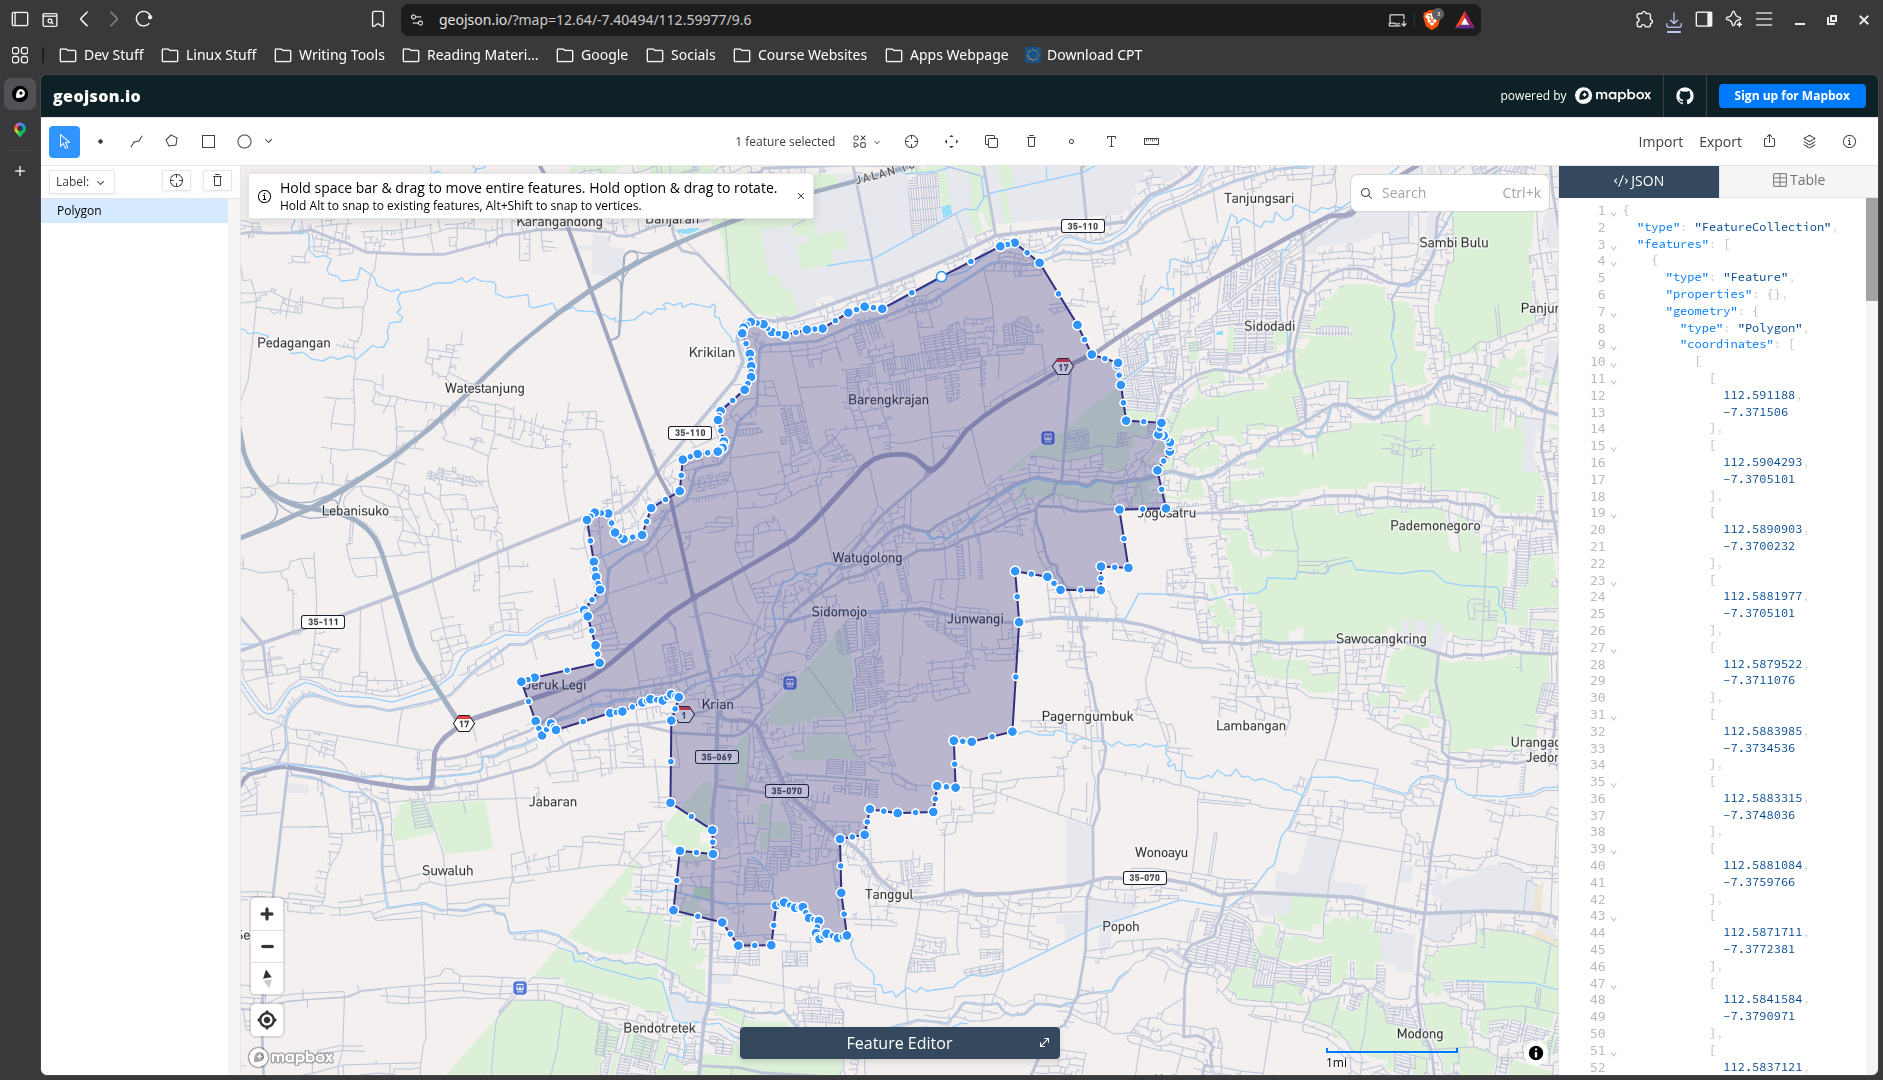

### 2. Memodifikasi Koordinat yang Ada di Tugas 1

Pertama-tama, saya membuka tugas ke-1 dan mencari cell berisi koordinat (yang lama):

> 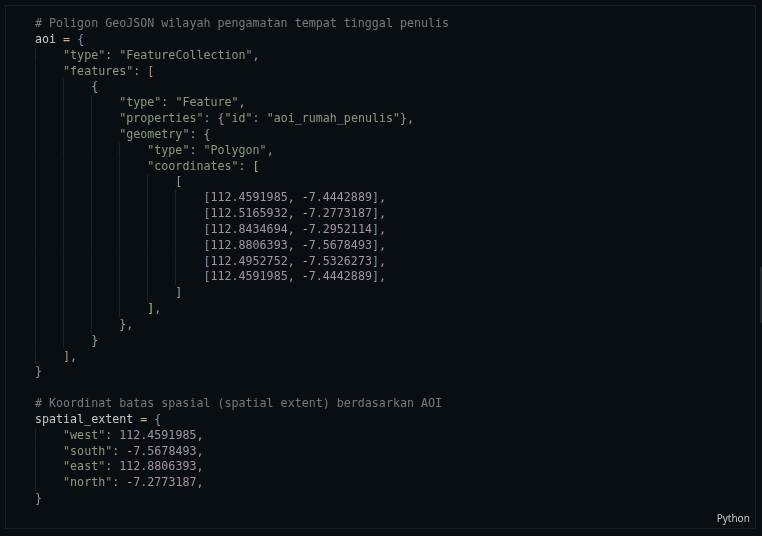

Lalu, ubah koordinat sesuai yang ada di Geojson.io:

> 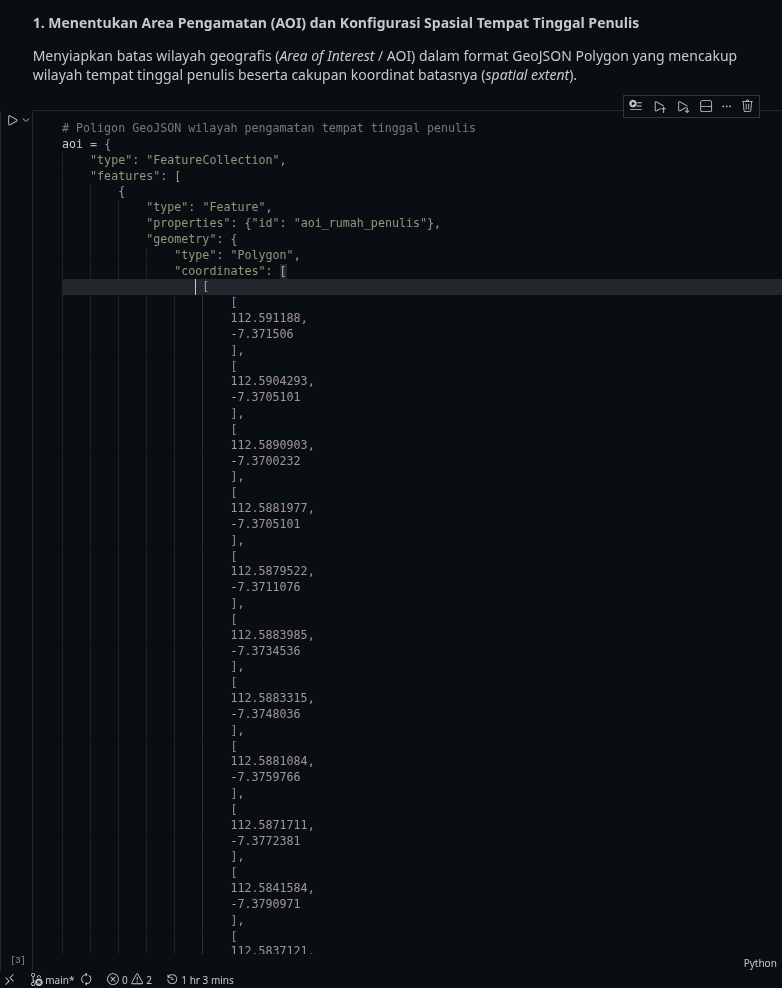

### 3. Memilih Hanya Polutan yang Diperlukan

Selanjutnya, pergi ke cell yang berisi list polutan yang diambil:

> 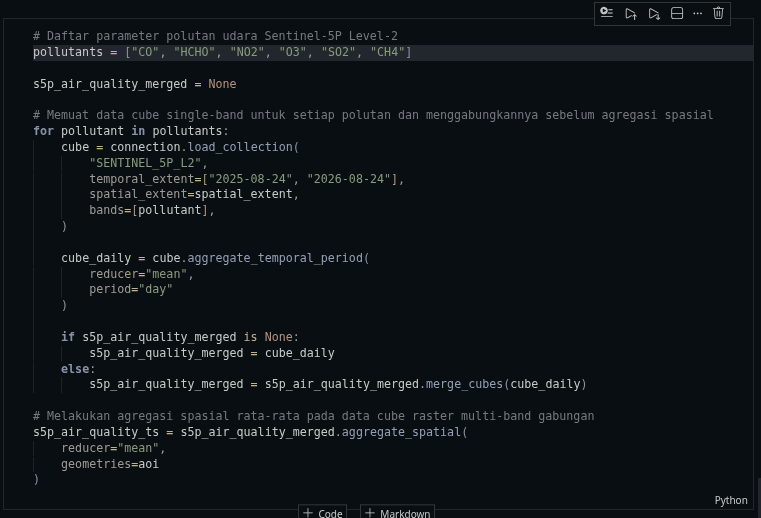

Bisa dilihat, di list `pollutants` terdapat 6 polutan. Disini, saya hanya akan mengambil 4 polutan, yaitu:

1. CO
2. SO2
3. NO2
4. CH4

Maka, selanjutnya modifikasi isi dari list `pollutants` agar menjadi seperti berikut:

> 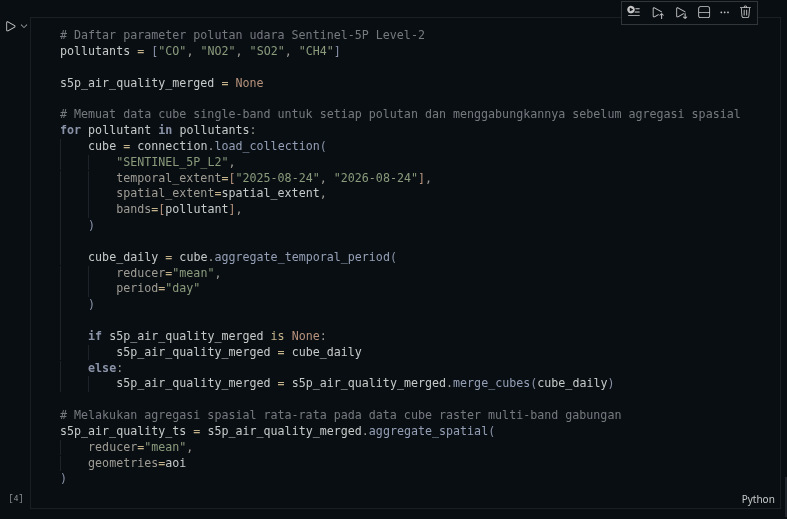

### 4. Menghapus Grafik dari Polutan yang Tidak Ada

Cari _cells_  yang berisi grafik + tidak ada elemen polutannya.

1. Hapus HCHO:

> 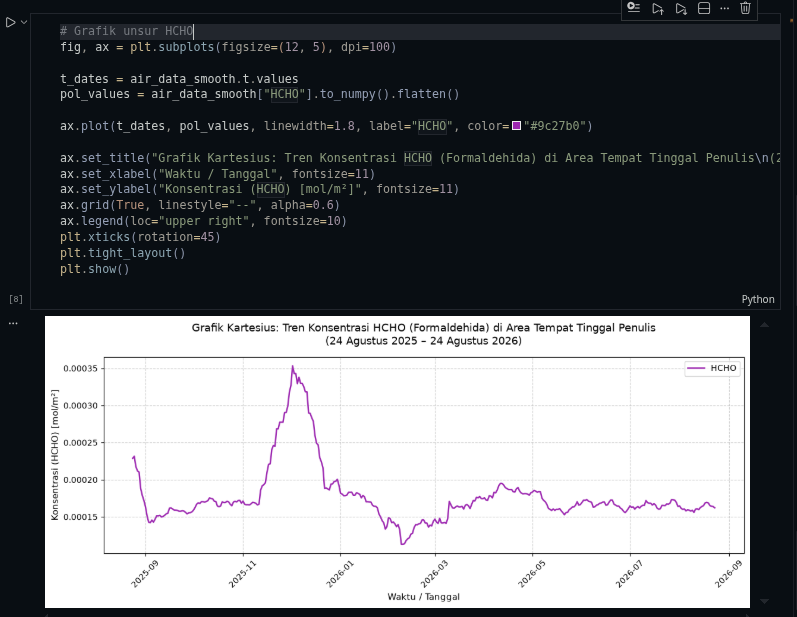

2. Hapus O3:

> 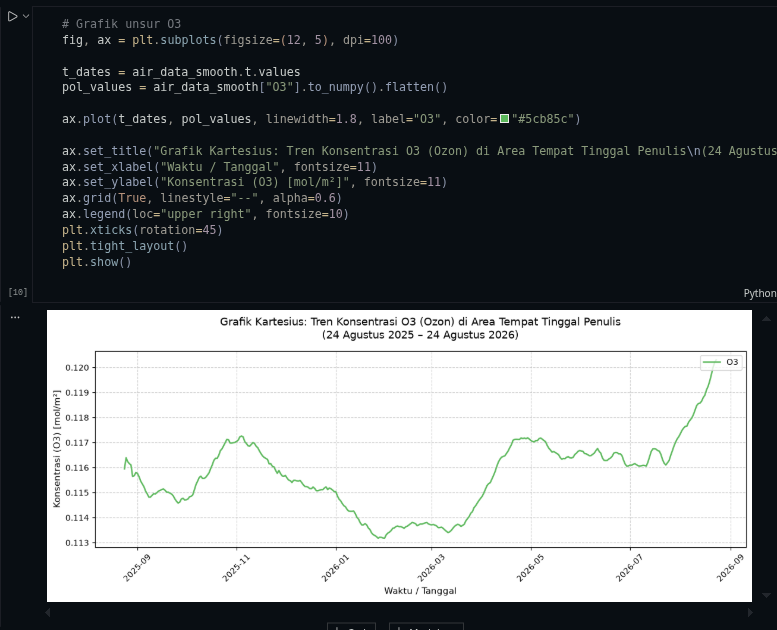

### 6. Identifikasi AOI Menggunakan Folium (Data Understanding)

#### Visualisasi Peta Interaktif Area Pengamatan (AOI)

Untuk memperjelas pemahaman spasial (*spatial understanding*) terhadap wilayah pengamatan dalam kerangka kerja CRISP-DM, kita membuat visualisasi peta interaktif menggunakan *library* **Folium**. Peta ini menampilkan:

1. **Poligon AOI (Area of Interest)**: Wilayah Kecamatan Krian, Sidoarjo yang didefinisikan melalui koordinat GeoJSON.
2. **Marker Lokasi Utama**: Titik pusat koordinat tempat tinggal penulis sebagai referensi pengamatan.
3. **Layer Peta Interaktif**: Memungkinkan zoom, pan, dan eksplorasi visual area pengamatan.

Visualisasi ini membantu dalam fase *Data Understanding* untuk memahami konteks geografis dari data kualitas udara yang dikumpulkan.

In [43]:
import folium
from folium.plugins import HeatMap

# Pusat koordinat lokasi tempat tinggal penulis (Kecamatan Krian, Sidoarjo)
center_lat, center_lon = -7.40, 112.59

# Inisialisasi peta interaktif Folium
peta_aoi = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=13,
    tiles="OpenStreetMap"
)

# Menambahkan Marker Tempat Tinggal Penulis
folium.Marker(
    location=[center_lat, center_lon],
    popup="<b>Lokasi Pengamatan Utama</b><br>Area Tempat Tinggal Penulis (Kecamatan Krian, Sidoarjo)",
    tooltip="Rumah Penulis (Krian, Sidoarjo)",
    icon=folium.Icon(color="red", icon="info-sign"),
).add_to(peta_aoi)

# Menambahkan kontrol layer pada peta
folium.LayerControl().add_to(peta_aoi)

# Menampilkan peta interaktif
peta_aoi

### 5. Terakhir, Run Ulang Seluruh Cell dari Tugas 1 yang Telah Dimodifikasi

Note:
> Terdapat beberapa hal yang aku ubah, tetapi tidak aku cantumkan. Seperti nama output file `.nc`, nama output file `.csv`

Hasil Tabel (_Snapshot_):

> 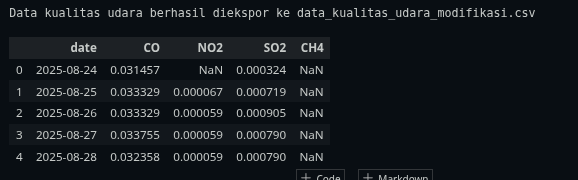

Grafik CO:

> 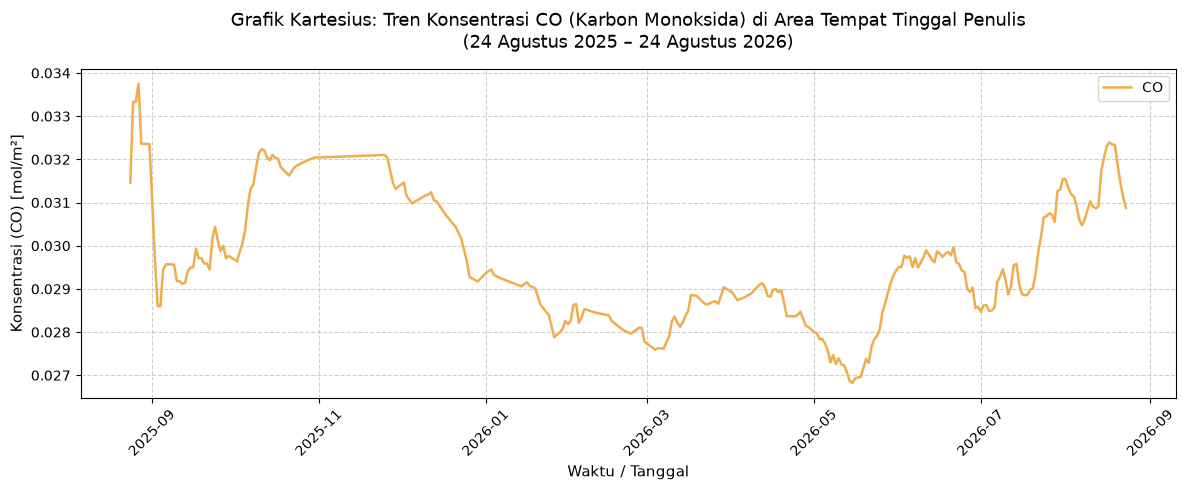

Grafik NO2:

> 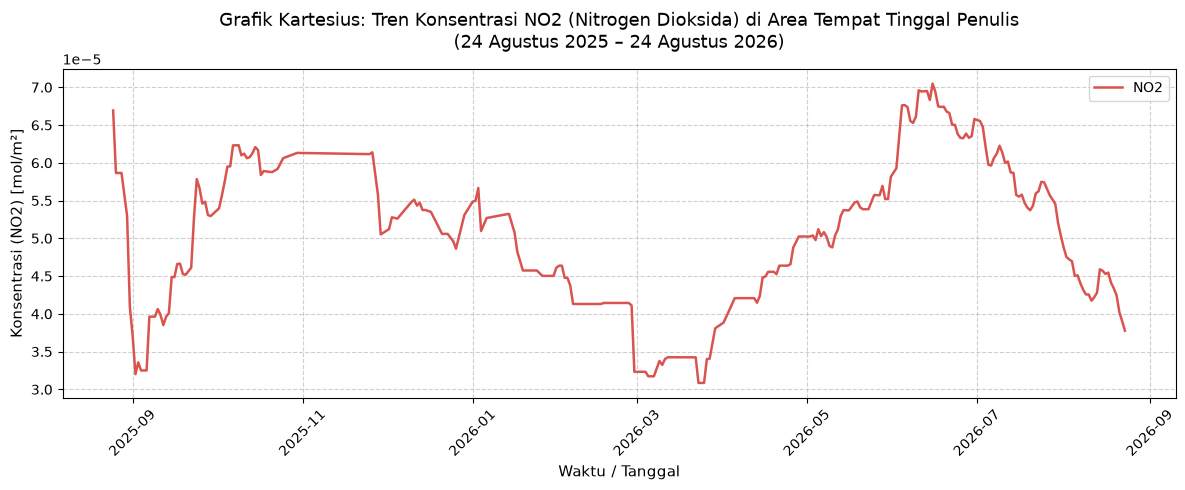

Grafik SO2:

> 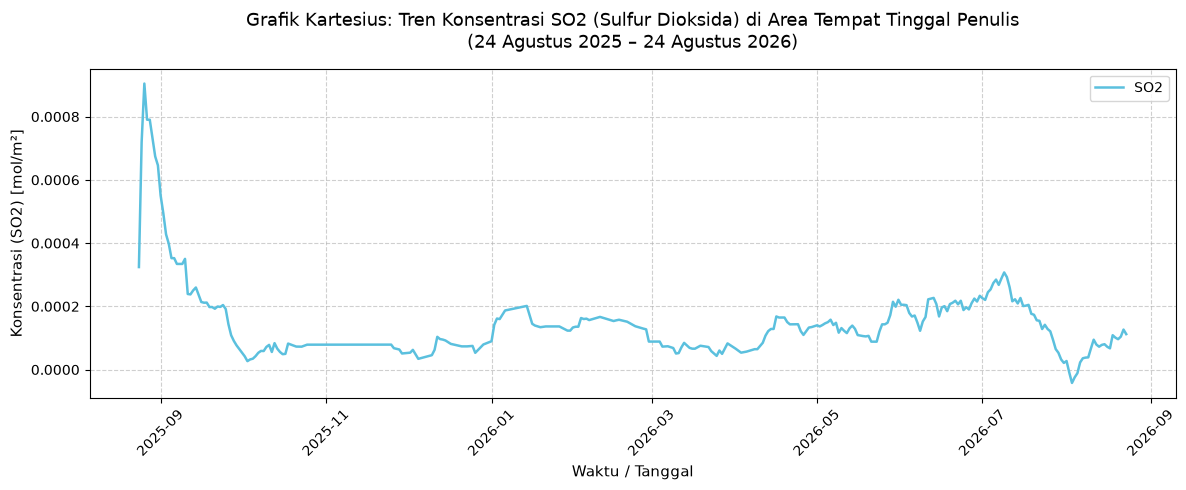

Grafik CH4:

> 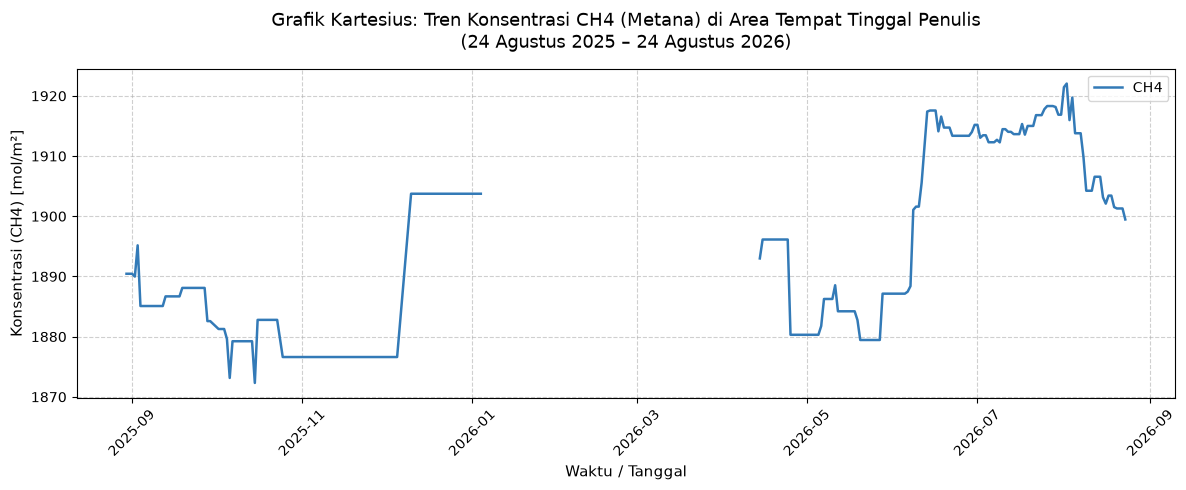

## Mencari dan Menangani _Missing Values_

### 1. Memuat Dataset dan Identifikasi Awal Missing Values

#### Memuat Dataset Kualitas Udara Modifikasi

Dataset yang digunakan adalah berkas CSV hasil modifikasi dari Tugas 1, yaitu `data_kualitas_udara_modifikasi.csv`. Dataset ini berisi rekaman deret waktu untuk 4 polutan utama (**CO**, **NO2**, **SO2**, dan **CH4**) pada cakupan wilayah Kecamatan Krian (Sidoarjo). Kita memuat dataset ini menggunakan *library* Pandas untuk memeriksa beberapa baris pertama data.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
# Memuat dataset kualitas udara hasil modifikasi dari Tugas 1
df = pd.read_csv("../tugas-1/data_kualitas_udara_modifikasi.csv")
df.head(10)

,date,CO,NO2,SO2,CH4
0,2025-08-24,0.031457,NaN,0.000324,NaN
1,2025-08-25,0.033329,0.000067,0.000719,NaN
2,2025-08-26,0.033329,0.000059,0.000905,NaN
3,2025-08-27,0.033755,0.000059,0.000790,NaN
4,2025-08-28,0.032358,0.000059,0.000790,NaN
5,2025-08-29,NaN,NaN,NaN,NaN
6,2025-08-30,0.032358,0.000053,0.000674,1890.448730
7,2025-08-31,0.032358,0.000041,0.000646,1890.448730
8,2025-09-01,0.030997,0.000037,0.000551,1890.448730
9,2025-09-02,0.029674,0.000032,0.000494,1889.981628


#### Memeriksa Informasi Struktur dan Tipe Data

Pemeriksaan struktur dataset meliputi jumlah baris, jumlah kolom, tipe data masing-masing atribut, serta jumlah nilai *non-null*. Hal ini penting untuk memastikan seluruh kolom polutan bertipe numerik (`float64`) dan kolom tanggal bertipe `object` yang siap dikonversi ke format tanggal (*datetime*).

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    365 non-null    object 
 1   CO      258 non-null    float64
 2   NO2     257 non-null    float64
 3   SO2     258 non-null    float64
 4   CH4     200 non-null    float64
dtypes: float64(4), object(1)
memory usage: 14.4+ KB


#### Menghitung Jumlah dan Persentase Missing Values per Kolom

Untuk mengetahui sebaran dan besaran data yang hilang pada setiap atribut polutan, kita menghitung total nilai kosong (*null/NaN*) beserta persentasenya terhadap keseluruhan total rentang waktu pengamatan 1 tahun penuh (365 hari kalender, 24 Agustus 2025 s.d. 23 Agustus 2026).

In [47]:
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Jumlah Missing (Baris)': missing_count,
    'Persentase Missing (%)': missing_percentage.round(2)
})

missing_summary

,Jumlah Missing (Baris),Persentase Missing (%)
date,0,0.00
CO,107,29.32
NO2,108,29.59
SO2,107,29.32
CH4,165,45.21


### 2. Analisis Pola dan Visualisasi Missing Values

#### Menelusuri Baris-Baris yang Mengandung Missing Values

Berdasarkan rekapitulasi data hilang pada rentang 365 hari kalender pengamatan:

- Kolom **CO** memiliki 107 baris kosong (29.32%) pada hari-hari tanpa rekaman satelit.
- Kolom **NO2** memiliki 108 baris kosong (29.59%), terdiri dari 107 hari tanpa rekaman satelit dan 1 observasi kosong pada tanggal 2025-08-24.
- Kolom **SO2** memiliki 107 baris kosong (29.32%) pada hari-hari tanpa rekaman satelit.
- Kolom **CH4** memiliki 165 baris kosong (45.21%) yang mencakup hari tanpa rekaman satelit serta ketiadaan data metana pada periode tertentu.

Berikut ditampilkan sampel baris data yang mengandung nilai kosong tersebut:

In [48]:
# Menampilkan baris data yang memiliki setidaknya satu nilai kosong (null)
df_missing_rows = df[df.isnull().any(axis=1)]
df_missing_rows.head(15)

,date,CO,NO2,SO2,CH4
0,2025-08-24,0.031457,NaN,0.000324,NaN
1,2025-08-25,0.033329,0.000067,0.000719,NaN
2,2025-08-26,0.033329,0.000059,0.000905,NaN
3,2025-08-27,0.033755,0.000059,0.000790,NaN
4,2025-08-28,0.032358,0.000059,0.000790,NaN
5,2025-08-29,NaN,NaN,NaN,NaN
15,2025-09-08,NaN,NaN,NaN,NaN
37,2025-09-30,NaN,NaN,NaN,NaN
38,2025-10-01,NaN,NaN,NaN,NaN
56,2025-10-19,NaN,NaN,NaN,NaN


#### Visualisasi Sebaran Missing Values pada Sinyal Deret Waktu

Untuk memahami pola keterputusan data sepanjang periode pengamatan 1 tahun (24 Agustus 2025 – 23 Agustus 2026), kita membuat grafik garis deret waktu untuk masing-masing polutan serta menandai posisi titik data yang hilang menggunakan penanda silang merah (*red cross*).

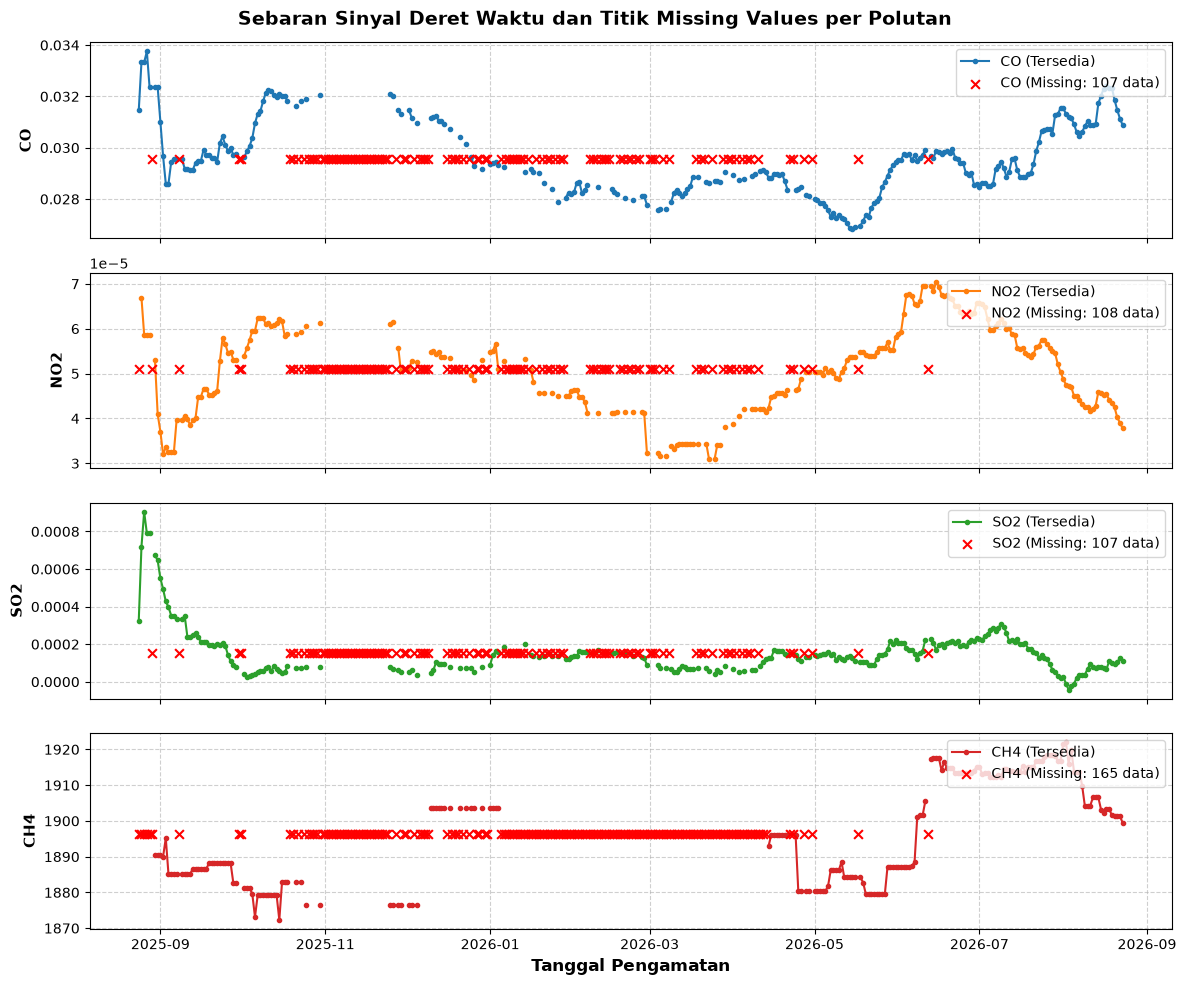

In [49]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
pollutants = ['CO', 'NO2', 'SO2', 'CH4']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

df_plot = df.copy()
df_plot['date'] = pd.to_datetime(df_plot['date'])

for i, p in enumerate(pollutants):
    axes[i].plot(df_plot['date'], df_plot[p], label=f'{p} (Tersedia)', color=colors[i], marker='o', markersize=3, linestyle='-')
    null_mask = df_plot[p].isnull()
    if null_mask.sum() > 0:
        null_dates = df_plot.loc[null_mask, 'date']
        axes[i].scatter(null_dates, [df_plot[p].dropna().mean()] * len(null_dates), color='red', marker='x', s=40, label=f'{p} (Missing: {null_mask.sum()} data)', zorder=5)
    axes[i].set_ylabel(p, fontsize=11, fontweight='bold')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Tanggal Pengamatan', fontsize=12, fontweight='bold')
plt.suptitle('Sebaran Sinyal Deret Waktu dan Titik Missing Values per Polutan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3. Penanganan Missing Values Menggunakan Teknik Imputasi

#### Pemilihan Metode Imputasi Deret Waktu (Linear Interpolation)

Pada data deret waktu (*time series*), observasi memiliki ketergantungan temporal (autokorelasi) di mana nilai pada suatu hari memiliki korelasi kuat dengan hari-hari yang berdekatan. Oleh karena itu, metode imputasi sederhana seperti rata-rata (*mean*) atau median tidak disarankan karena dapat menghilangkan variabilitas temporal dan menghasilkan diskontinuitas buatan (*flat lines*).

Teknik yang paling tepat adalah **Interpolasi Linier (*Linear Interpolation*)** dengan parameter `limit_direction='both'`:

1. Untuk celah data di bagian tengah (seperti pada **CH4** indeks 79–131), interpolasi linier menghubungkan titik data sebelum dan sesudah celah secara bertahap dan halus.
2. Untuk data kosong di bagian awal deret waktu (seperti pada **NO2** dan **CH4** indeks 0–4), parameter `limit_direction='both'` akan menerapkan *backward fill* dari nilai valid pertama terdekat, sehingga batas awal tetap terisi secara konsisten.

#### Melakukan Imputasi Interpolasi Linier pada Kolom NO2 dan CH4

Kita membuat salinan *dataframe* `df_imputed` kemudian menerapkan metode `.interpolate(method='linear', limit_direction='both')` pada seluruh kolom polutan (**CO**, **NO2**, **SO2**, dan **CH4**).

In [50]:
# Membuat salinan dataframe dan menerapkan interpolasi linier dua arah pada seluruh polutan
df_imputed = df.copy()
for p in ['CO', 'NO2', 'SO2', 'CH4']:
    df_imputed[p] = df_imputed[p].interpolate(method='linear', limit_direction='both')

# Menampilkan 10 baris pertama hasil imputasi
df_imputed.head(10)

,date,CO,NO2,SO2,CH4
0,2025-08-24,0.031457,0.000067,0.000324,1890.448730
1,2025-08-25,0.033329,0.000067,0.000719,1890.448730
2,2025-08-26,0.033329,0.000059,0.000905,1890.448730
3,2025-08-27,0.033755,0.000059,0.000790,1890.448730
4,2025-08-28,0.032358,0.000059,0.000790,1890.448730
5,2025-08-29,0.032358,0.000056,0.000732,1890.448730
6,2025-08-30,0.032358,0.000053,0.000674,1890.448730
7,2025-08-31,0.032358,0.000041,0.000646,1890.448730
8,2025-09-01,0.030997,0.000037,0.000551,1890.448730
9,2025-09-02,0.029674,0.000032,0.000494,1889.981628


### 4. Evaluasi dan Verifikasi Hasil Imputasi

#### Memeriksa Ketiadaan Nilai Kosong Pasca-Imputasi

Setelah proses imputasi selesai dijalankan, kita memeriksa kembali jumlah *missing values* pada seluruh kolom untuk memastikan bahwa seluruh atribut kini memiliki data lengkap tanpa ada nilai kosong (*NaN*) yang tersisa.

In [51]:
# Verifikasi jumlah nilai kosong setelah proses imputasi
df_imputed.isnull().sum()

date    0
CO      0
NO2     0
SO2     0
CH4     0
dtype: int64

#### Visualisasi Perbandingan Sinyal Sebelum dan Sesudah Imputasi

Untuk memvalidasi bahwa hasil interpolasi linier menyatu secara mulus dengan sinyal asli dan tidak mendistorsi tren umum data, kita membuat grafik perbandingan antara sinyal sebelum imputasi (garis solid berwarna) dengan sinyal hasil imputasi (garis putus-putus merah/hijau) pada polutan **NO2** dan **CH4**.

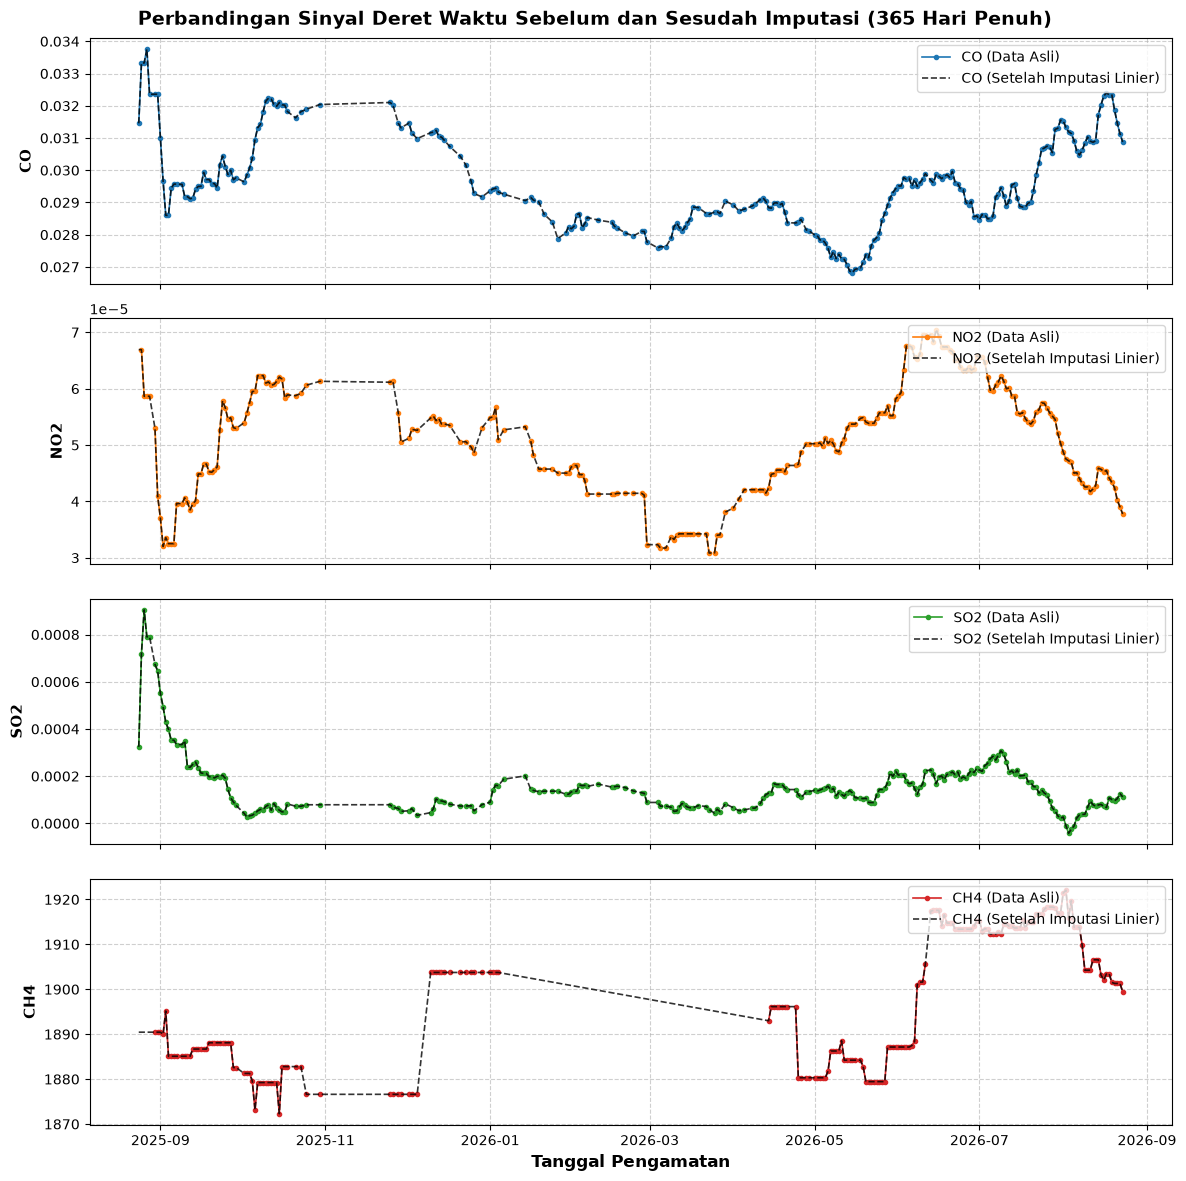

In [52]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
pollutants = ['CO', 'NO2', 'SO2', 'CH4']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

df_imputed_plot = df_imputed.copy()
df_imputed_plot['date'] = pd.to_datetime(df_imputed_plot['date'])

for i, p in enumerate(pollutants):
    axes[i].plot(df_plot['date'], df_plot[p], label=f'{p} (Data Asli)', color=colors[i], marker='o', markersize=3, linewidth=1.2)
    axes[i].plot(df_imputed_plot['date'], df_imputed_plot[p], label=f'{p} (Setelah Imputasi Linier)', color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    axes[i].set_ylabel(p, fontsize=11, fontweight='bold')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, linestyle='--', alpha=0.6)

axes[-1].set_xlabel('Tanggal Pengamatan', fontsize=12, fontweight='bold')
plt.suptitle('Perbandingan Sinyal Deret Waktu Sebelum dan Sesudah Imputasi (365 Hari Penuh)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Menyimpan Dataset Bersih Hasil Imputasi

Setelah diverifikasi lengkap dan valid, dataset hasil imputasi disimpan ke dalam berkas CSV bernama `data_kualitas_udara_imputed.csv` di dalam direktori `src/tugas-3/`. Berkas ini akan menjadi dasar untuk tahapan identifikasi serta penanganan *outlier*, dilanjutkan ke tahap ekstraksi fitur menggunakan TSFEL.

In [53]:
# Menyimpan dataframe hasil imputasi ke dalam berkas CSV baru
output_imputed_csv = 'data_kualitas_udara_imputed.csv'
df_imputed.to_csv(output_imputed_csv, index=False)
print(f"Dataset hasil imputasi berhasil disimpan ke '{output_imputed_csv}' dengan ukuran {df_imputed.shape}.")

Dataset hasil imputasi berhasil disimpan ke 'data_kualitas_udara_imputed.csv' dengan ukuran (365, 5).


## Mengidentifikasi dan Menangani/Memperbaiki _Outlier_

### 1. Identifikasi dan Deteksi Outlier Menggunakan Metode IQR

#### Konsep Dasar dan Formula Interquartile Range (IQR)

Pencilan (*outlier*) adalah nilai observasi yang menyimpang secara signifikan dari pola sebaran data secara keseluruhan. Pada data atmosfer dan kualitas udara, lonjakan nilai sesaat kerap terjadi akibat dinamika cuaca, emisi industri mendadak, atau gangguan sensor.

Metode yang digunakan untuk mendeteksi pencilan adalah **Metode Rentang Antarkuartil (*Interquartile Range* / IQR)** atau dikenal sebagai *Tukey's Fences*. Metode ini bersifat **non-parametrik dan *robust*** terhadap data yang memiliki distribusi tidak simetris (*skewed*), sehingga tidak mudah terdistorsi oleh nilai ekstrem dibandingkan metode berbasis rata-rata dan standar deviasi (*Z-score*).

Formula perhitungan batas ambang toleransi IQR dirumuskan sebagai berikut:

$$\text{IQR} = Q_3 - Q_1$$

$$\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}$$

$$\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$$

Nilai $x$ dikategorikan sebagai *outlier* jika memenuhi kondisi $x < \text{Batas Bawah}$ atau $x > \text{Batas Atas}$.

#### Menghitung Batas Ambang dan Jumlah Outlier per Polutan

Kita memuat dataset `data_kualitas_udara_imputed.csv` hasil imputasi dari tahap sebelumnya. Kemudian, kita menghitung nilai kuartil pertama ($Q_1$), kuartil ketiga ($Q_3$), nilai IQR, batas bawah, batas atas, serta jumlah dan persentase data pencilan untuk keempat polutan (**CO**, **NO2**, **SO2**, dan **CH4**).

In [54]:
# Memuat dataset hasil imputasi dari tahap sebelumnya
df_imputed = pd.read_csv('data_kualitas_udara_imputed.csv')

pollutants = ['CO', 'NO2', 'SO2', 'CH4']
outlier_stats = []

for p in pollutants:
    q1 = df_imputed[p].quantile(0.25)
    q3 = df_imputed[p].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df_imputed[p] < lower_bound) | (df_imputed[p] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = (outlier_count / len(df_imputed)) * 100
    
    outlier_stats.append({
        'Polutan': p,
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Batas Bawah': lower_bound,
        'Batas Atas': upper_bound,
        'Jumlah Outlier': outlier_count,
        'Persentase (%)': round(outlier_pct, 2)
    })

df_outlier_summary = pd.DataFrame(outlier_stats)
df_outlier_summary

,Polutan,Q1 (25%),Q3 (75%),IQR,Batas Bawah,Batas Atas,Jumlah Outlier,Persentase (%)
0,CO,0.028558,0.031027,0.002469,0.024854,0.034731,0,0.00
1,NO2,0.000043,0.000059,0.000016,0.000019,0.000083,0,0.00
2,SO2,0.000075,0.000171,0.000096,-0.000069,0.000315,18,4.93
3,CH4,1884.213989,1903.634126,19.420137,1855.083784,1932.764331,0,0.00


#### Visualisasi Boxplot dan Identifikasi Nilai Ekstrem

Berdasarkan rekapitulasi perhitungan IQR di atas, hasil deteksi menunjukkan bahwa:

- Kolom **CO**, **NO2**, dan **CH4** memiliki **0 data pencilan (0.00%)**, artinya seluruh nilai berada dalam batas sebaran normal yang wajar.
- Kolom **SO2** memiliki **18 baris pencilan (4.93%)** di atas batas toleransi $3.1516 \times 10^{-4} \text{ mol/m}^2$.

Berikut ditampilkan visualisasi *boxplot* untuk keempat polutan guna melihat sebaran distribusi dan letak titik-titik pencilan secara visual:

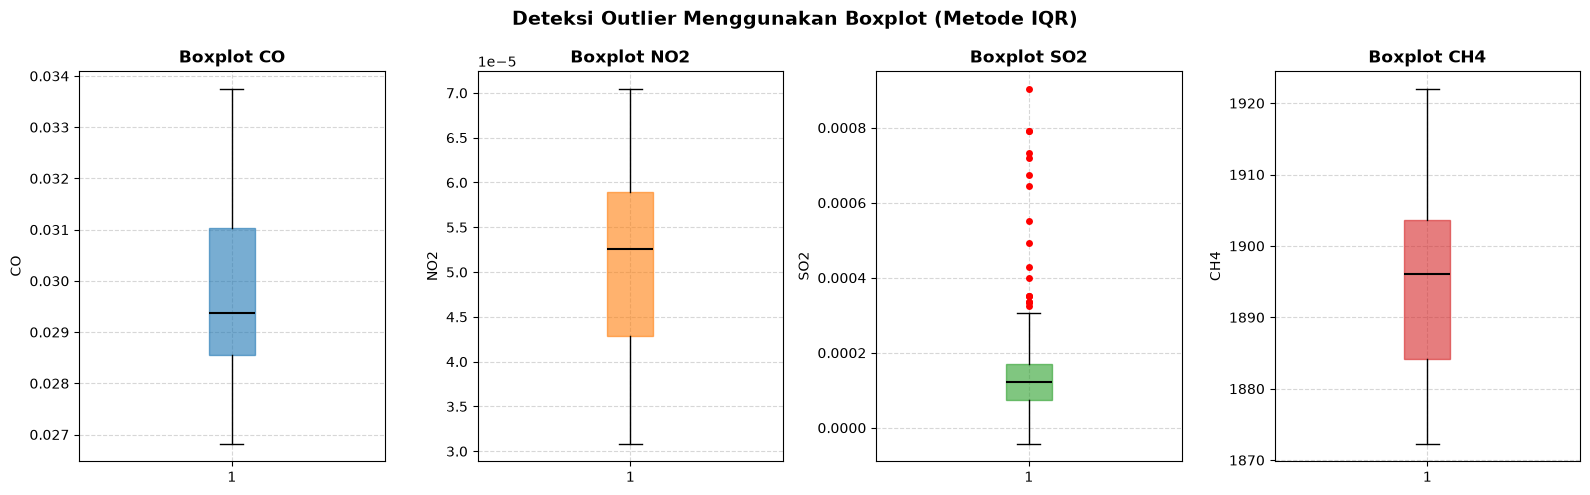

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, p in enumerate(pollutants):
    axes[i].boxplot(df_imputed[p], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], color=colors[i], alpha=0.6),
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5, markeredgecolor='none'))
    axes[i].set_title(f'Boxplot {p}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(p, fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Deteksi Outlier Menggunakan Boxplot (Metode IQR)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Untuk mengetahui kapan pencilan pada polutan **SO2** terjadi, kita menampilkan daftar baris data yang melebihi batas atas IQR:

In [56]:
# Menampilkan baris data pencilan pada kolom SO2
so2_q1 = df_imputed['SO2'].quantile(0.25)
so2_q3 = df_imputed['SO2'].quantile(0.75)
so2_iqr = so2_q3 - so2_q1
so2_upper = so2_q3 + 1.5 * so2_iqr
so2_lower = so2_q1 - 1.5 * so2_iqr

so2_outliers = df_imputed[df_imputed['SO2'] > so2_upper][['date', 'SO2']]
print(f"Total baris outlier SO2: {len(so2_outliers)} baris")
so2_outliers.head(10)

Total baris outlier SO2: 18 baris


,date,SO2
0,2025-08-24,0.000324
1,2025-08-25,0.000719
2,2025-08-26,0.000905
3,2025-08-27,0.000790
4,2025-08-28,0.000790
5,2025-08-29,0.000732
6,2025-08-30,0.000674
7,2025-08-31,0.000646
8,2025-09-01,0.000551
9,2025-09-02,0.000494


#### Perbandingan Deteksi Outlier: Metode IQR vs Z-Score

Untuk memperkuat validitas hasil deteksi pencilan, kita membandingkan metode **IQR (*Interquartile Range*)** yang telah digunakan di atas dengan metode **Z-Score** sebagai pembanding.

**Metode Z-Score** menghitung seberapa jauh suatu nilai menyimpang dari rata-rata (*mean*) dalam satuan standar deviasi:

$$Z = \frac{x - \mu}{\sigma}$$

Suatu nilai dikategorikan sebagai *outlier* jika $|Z| > 3$ (menyimpang lebih dari 3 standar deviasi).

**Perbedaan filosofi kedua metode:**

| Aspek | IQR (*Tukey's Fences*) | Z-Score |
| :--- | :--- | :--- |
| Sifat | Non-parametrik (*robust*) | Parametrik |
| Basis | Kuartil ($Q_1$, $Q_3$) | Mean ($\mu$) dan Std Dev ($\sigma$) |
| Asumsi | Tidak mengasumsikan distribusi tertentu | Mengasumsikan distribusi mendekati normal |
| Sensitivitas | Lebih sensitif pada distribusi *skewed* | Lebih konservatif pada distribusi *skewed* |


In [57]:
# Perbandingan deteksi outlier: IQR vs Z-Score
comparison_results = []

for p in pollutants:
    # Metode IQR
    q1 = df_imputed[p].quantile(0.25)
    q3 = df_imputed[p].quantile(0.75)
    iqr = q3 - q1
    iqr_lower = q1 - 1.5 * iqr
    iqr_upper = q3 + 1.5 * iqr
    iqr_outliers = ((df_imputed[p] < iqr_lower) | (df_imputed[p] > iqr_upper)).sum()

    # Metode Z-Score (|Z| > 3)
    mean_val = df_imputed[p].mean()
    std_val = df_imputed[p].std()
    z_scores = (df_imputed[p] - mean_val) / std_val
    zscore_outliers = (z_scores.abs() > 3).sum()

    comparison_results.append({
        'Polutan': p,
        'Outlier (IQR)': iqr_outliers,
        'Outlier (Z-Score |Z|>3)': zscore_outliers,
        'Selisih': iqr_outliers - zscore_outliers
    })

df_comparison = pd.DataFrame(comparison_results)
df_comparison

,Polutan,Outlier (IQR),Outlier (Z-Score |Z|>3),Selisih
0,CO,0,0,0
1,NO2,0,0,0
2,SO2,18,9,9
3,CH4,0,0,0


Berdasarkan tabel perbandingan di atas:

- **Metode IQR** mendeteksi **18 outlier** pada kolom **SO2**, sedangkan **Z-Score** hanya mendeteksi **9 outlier** pada kolom yang sama.
- Pada kolom **CO**, **NO2**, dan **CH4**, kedua metode sepakat bahwa **tidak ada pencilan (0 outlier)**.
- Selisih antara IQR dan Z-Score pada SO2 menunjukkan bahwa **IQR lebih sensitif** dalam mendeteksi nilai-nilai ekstrem pada distribusi yang condong ke kanan (*right-skewed*), karena IQR berbasis kuartil yang tidak terpengaruh oleh nilai ekstrem itu sendiri.
- Sebaliknya, **Z-Score lebih konservatif** karena rata-rata (*mean*) dan standar deviasi (*std*) sudah terpengaruh oleh keberadaan outlier, sehingga ambang batas $3\sigma$ menjadi lebih longgar.

**Kesimpulan**: Metode **IQR dipilih sebagai acuan penanganan** karena lebih sesuai (*robust*) untuk data deret waktu atmosfer yang umumnya memiliki distribusi non-Gaussian (*skewed*).

Berikut adalah visualisasi perbandingan titik-titik data yang terdeteksi sebagai pencilan oleh masing-masing metode pada sinyal deret waktu **SO2**:

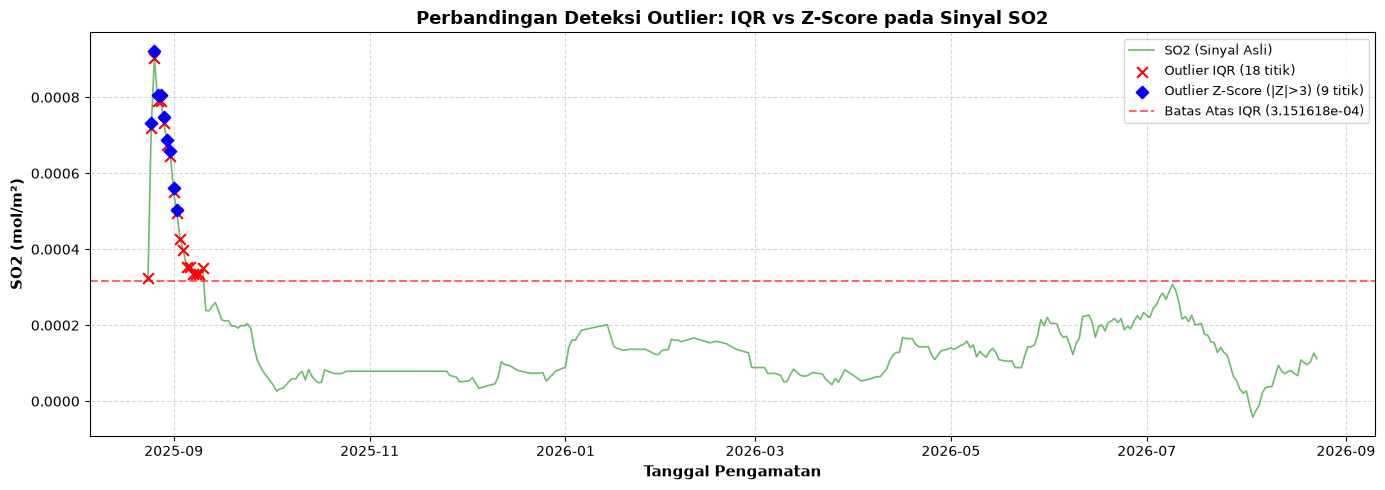

In [58]:
# Visualisasi perbandingan deteksi outlier IQR vs Z-Score pada sinyal SO2
fig, ax = plt.subplots(figsize=(14, 5))

dates = pd.to_datetime(df_imputed['date'])
so2_vals = df_imputed['SO2']

# Sinyal SO2
ax.plot(dates, so2_vals, color='#2ca02c', linewidth=1.2, label='SO2 (Sinyal Asli)', alpha=0.7)

# IQR outlier mask
iqr_mask = (so2_vals < so2_lower) | (so2_vals > so2_upper)

# Z-Score outlier mask
z_scores_so2 = (so2_vals - so2_vals.mean()) / so2_vals.std()
zscore_mask = z_scores_so2.abs() > 3

# Plot IQR outliers
ax.scatter(dates[iqr_mask], so2_vals[iqr_mask], color='red', marker='x', s=60, zorder=5, label=f'Outlier IQR ({iqr_mask.sum()} titik)')

# Plot Z-Score outliers (offset sedikit agar tidak saling menutupi)
ax.scatter(dates[zscore_mask], so2_vals[zscore_mask] * 1.02, color='blue', marker='D', s=40, zorder=6, label=f'Outlier Z-Score (|Z|>3) ({zscore_mask.sum()} titik)')

# Garis batas IQR
ax.axhline(so2_upper, color='red', linestyle='--', alpha=0.6, label=f'Batas Atas IQR ({so2_upper:.6e})')

ax.set_title('Perbandingan Deteksi Outlier: IQR vs Z-Score pada Sinyal SO2', fontsize=13, fontweight='bold')
ax.set_xlabel('Tanggal Pengamatan', fontsize=11, fontweight='bold')
ax.set_ylabel('SO2 (mol/m²)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 2. Penanganan Outlier Menggunakan Teknik Capping (Winsorization)

#### Pemilihan Teknik Capping untuk Menjaga Kontinuitas Deret Waktu

Dalam analisis data deret waktu (*time series*), penghapusan baris data pencilan (*dropping rows*) **sangat tidak disarankan** karena akan memotong rangkaian waktu harian dan merusak struktur autokorelasi temporal 365 hari penuh yang disyaratkan oleh TSFEL.

Oleh karena itu, teknik penanganan yang tepat adalah **Penyetaraan Ambang Batas (*Capping / Winsorization*)**:

1. Nilai yang melebihi batas atas ($x > \text{Batas Atas}$) disetarakan nilainya tepat menjadi nilai batas atas ($\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$).
2. Nilai yang berada di bawah batas bawah ($x < \text{Batas Bawah}$) disetarakan tepat menjadi nilai batas bawah.

Teknik ini memastikan seluruh titik waktu 365 hari tetap utuh, sembari membatasi besaran nilai ekstrem agar tidak membiaskan perhitungan fitur pada tahap ekstraksi fitur TSFEL.

#### Menerapkan Capping pada Kolom SO2

Kita membuat salinan *dataframe* bernama `df_clean`, kemudian menerapkan fungsi `.clip(lower=so2_lower, upper=so2_upper)` pada kolom **SO2** untuk membatasi nilai maksimumnya sesuai batas atas IQR.

In [59]:
# Membuat salinan dataframe dan menerapkan Capping pada kolom SO2
df_clean = df_imputed.copy()
df_clean['SO2'] = df_clean['SO2'].clip(lower=so2_lower, upper=so2_upper)

print(f"Batas atas Capping SO2 : {so2_upper:.6e} mol/m²")
print(f"Nilai maksimum SO2 setelah Capping : {df_clean['SO2'].max():.6e} mol/m²")

Batas atas Capping SO2 : 3.151618e-04 mol/m²
Nilai maksimum SO2 setelah Capping : 3.151618e-04 mol/m²


### 3. Evaluasi dan Verifikasi Hasil Penanganan Outlier

#### Memeriksa Ketiadaan Outlier Pasca-Penanganan

Setelah proses *capping* dijalankan, kita melakukan verifikasi ulang menggunakan metode IQR pada seluruh atribut untuk memastikan bahwa tidak ada lagi nilai pencilan yang tersisa dan ringkasan statistik dataset berada dalam kondisi yang stabil.

In [60]:
# Verifikasi ulang deteksi outlier pasca-penanganan
clean_outlier_stats = []

for p in pollutants:
    q1 = df_clean[p].quantile(0.25)
    q3 = df_clean[p].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_mask = (df_clean[p] < lower_bound) | (df_clean[p] > upper_bound)
    outlier_count = outlier_mask.sum()
    
    clean_outlier_stats.append({
        'Polutan': p,
        'Min': df_clean[p].min(),
        'Max': df_clean[p].max(),
        'Mean': df_clean[p].mean(),
        'Std Dev': df_clean[p].std(),
        'Jumlah Outlier': outlier_count
    })

df_clean_summary = pd.DataFrame(clean_outlier_stats)
df_clean_summary

,Polutan,Min,Max,Mean,Std Dev,Jumlah Outlier
0,CO,0.026823,0.033755,0.029704,0.001506,0
1,NO2,0.000031,0.000070,0.000051,0.000010,0
2,SO2,-0.000042,0.000315,0.000130,0.000074,0
3,CH4,1872.310791,1922.044482,1894.848910,12.594469,0


#### Visualisasi Perbandingan Sinyal Sebelum dan Sesudah Capping

Untuk melihat secara nyata dampak dari penanganan pencilan, kita membandingkan sinyal deret waktu polutan **SO2** sebelum *capping* (menampilkan lonjakan ekstrem di awal periode) dengan sinyal setelah *capping* (lonjakan ekstrem terpangkas secara rapi pada garis batas atas).

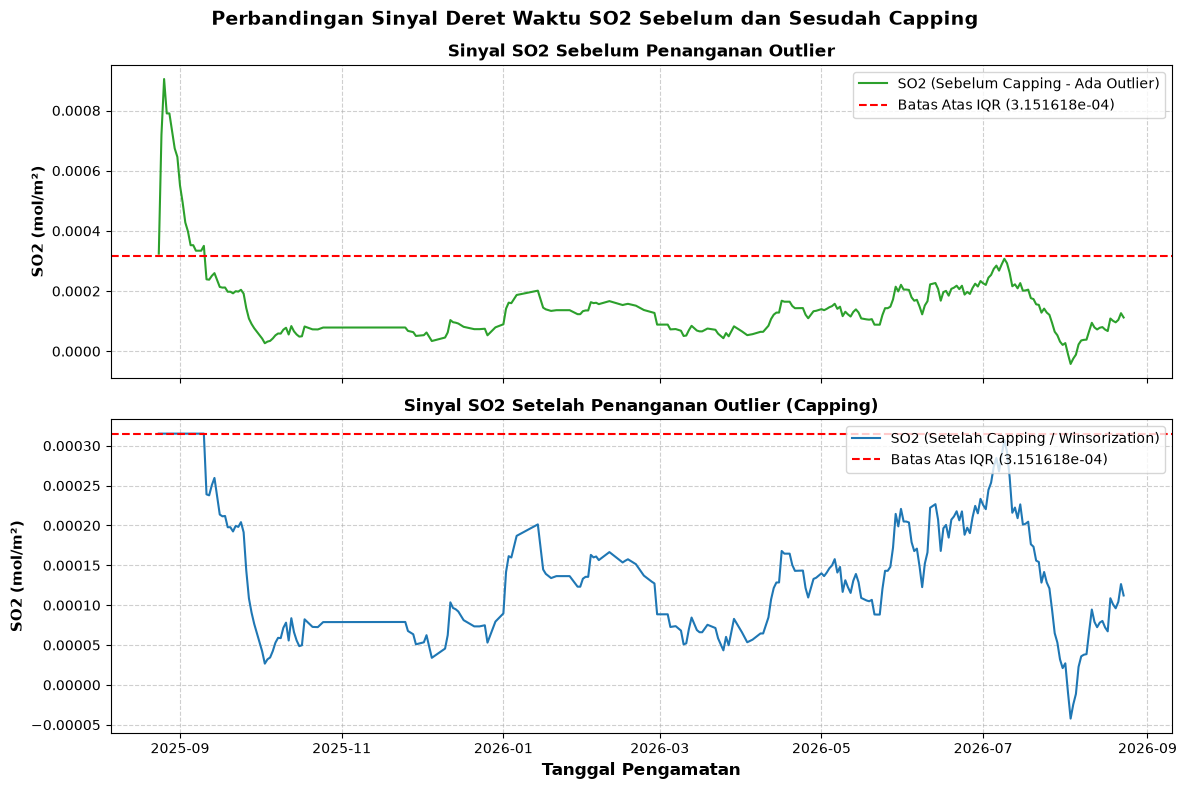

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

df_imputed_dates = pd.to_datetime(df_imputed['date'])

# Plot Sinyal Sebelum Capping
axes[0].plot(df_imputed_dates, df_imputed['SO2'], color='#2ca02c', label='SO2 (Sebelum Capping - Ada Outlier)', linewidth=1.5)
axes[0].axhline(so2_upper, color='red', linestyle='--', label=f'Batas Atas IQR ({so2_upper:.6e})')
axes[0].set_ylabel('SO2 (mol/m²)', fontsize=11, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_title('Sinyal SO2 Sebelum Penanganan Outlier', fontsize=12, fontweight='bold')

# Plot Sinyal Setelah Capping
axes[1].plot(df_imputed_dates, df_clean['SO2'], color='#1f77b4', label='SO2 (Setelah Capping / Winsorization)', linewidth=1.5)
axes[1].axhline(so2_upper, color='red', linestyle='--', label=f'Batas Atas IQR ({so2_upper:.6e})')
axes[1].set_ylabel('SO2 (mol/m²)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Tanggal Pengamatan', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_title('Sinyal SO2 Setelah Penanganan Outlier (Capping)', fontsize=12, fontweight='bold')

plt.suptitle('Perbandingan Sinyal Deret Waktu SO2 Sebelum dan Sesudah Capping', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Menyimpan Dataset Bersih Bebas Outlier

Dataset yang telah melalui tahapan imputasi *missing values* dan penanganan *outlier* kini berada dalam kondisi bersih, utuh, dan konsisten. Dataset ini disimpan ke dalam berkas `data_kualitas_udara_clean.csv` di direktori `src/tugas-3/`, yang akan digunakan sebagai masukan utama (*input*) pada proses ekstraksi fitur menggunakan *library* TSFEL.

> 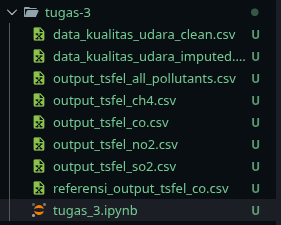

In [62]:
# Menyimpan dataframe bersih ke dalam berkas CSV baru
output_clean_csv = 'data_kualitas_udara_clean.csv'
df_clean.to_csv(output_clean_csv, index=False)
print(f"Dataset bersih bebas outlier berhasil disimpan ke '{output_clean_csv}' dengan ukuran {df_clean.shape}.")

Dataset bersih bebas outlier berhasil disimpan ke 'data_kualitas_udara_clean.csv' dengan ukuran (365, 5).


## Melakukan Ekstraksi Fitur Menggunakan _Library_ TSFEL

### 1. Daftar dan Deskripsi Fitur Ekstraksi TSFEL

#### Tabel 68 Fitur Ekstraksi TSFEL (Statistical, Temporal, dan Spectral)

TSFEL (*Time Series Feature Extraction Library*) menyediakan **68 fitur bawaan** yang terbagi ke dalam tiga domain utama:

1. **Domain Statistik (*Statistical*)**: Menghitung karakteristik distribusi probabilitas, tendensi pusat, variabilitas, dan sifat statistik sinyal.
2. **Domain Temporal**: Menangkap pola-pola perubahan amplitudo, autokorelasi, lintasan kurva, serta kompleksitas fraktal terhadap waktu.
3. **Domain Spektral (*Spectral*)**: Menganalisis kandungan frekuensi sinyal menggunakan transformasi Fourier, transformasi Wavelet, dan spektrogram.

Berikut adalah tabel lengkap 68 fitur yang disediakan oleh TSFEL beserta kode kolom, nama fungsi, domain, dan deskripsinya:

| No | Nama Method / Fungsi | Deskripsi / Fungsi Fitur |
| :---: | :--- | :--- |
| 1 | `abs_energy(signal)` | Menghitung total energi absolut sinyal deret waktu ($E = \sum x_i^2$). |
| 2 | `auc(signal, fs)` | Menghitung luas area di bawah kurva sinyal (*Area Under the Curve*) dengan aturan trapesium. |
| 3 | `autocorr(signal)` | Menghitung lag pertama di mana autokorelasi bernilai kurang dari ambang batas $1/e$. |
| 4 | `average_power(signal, fs)` | Menghitung rata-rata daya spektral sinyal per satuan waktu. |
| 5 | `calc_centroid(signal, fs)` | Menghitung titik pusat massa (*centroid*) temporal dari sinyal deret waktu. |
| 6 | `calc_max(signal)` | Menghitung nilai maksimum dari seluruh titik data sinyal. |
| 7 | `calc_mean(signal)` | Menghitung nilai rata-rata aritmetika dari sinyal deret waktu. |
| 8 | `calc_median(signal)` | Menghitung nilai median (titik tengah data terurut) dari sinyal. |
| 9 | `calc_min(signal)` | Menghitung nilai minimum dari seluruh titik data sinyal. |
| 10 | `calc_std(signal)` | Menghitung standar deviasi (akar variansi) sebagai ukuran sebaran nilai sinyal. |
| 11 | `calc_var(signal)` | Menghitung variansi (dispersi kuadratik) dari sinyal terhadap rata-ratanya. |
| 12 | `dfa(signal)` | Menghitung *Detrended Fluctuation Analysis* untuk mengukur persistensi ketergantungan jarak jauh. |
| 13 | `distance(signal)` | Menghitung panjang kumulatif lintasan kurva sinyal deret waktu. |
| 14 | `ecdf(signal)` | Menghitung nilai fungsi distribusi kumulatif empiris (*Empirical Cumulative Distribution Function*). |
| 15 | `ecdf_percentile(signal)` | Menghitung nilai persentil tertentu berdasarkan kurva ECDF sinyal. |
| 16 | `ecdf_percentile_count(signal)` | Menghitung jumlah sampel data kumulatif pada persentil ECDF tertentu. |
| 17 | `ecdf_slope(signal)` | Menghitung kemiringan (*slope*) dari kurva ECDF pada rentang persentil tertentu. |
| 18 | `entropy(signal)` | Menghitung entropi informasi Shannon untuk mengukur derajat keacakan distribusi sinyal. |
| 19 | fs)` | Menghitung frekuensi dasar (*fundamental frequency*) dominan dari sinyal. |
| 20 | `higuchi_fractal_dimension(signal)` | Menghitung dimensi fraktal Higuchi untuk mengukur kompleksitas bentuk kurva sinyal. |
| 21 | `hist_mode(signal)` | Menghitung nilai modus (nilai paling sering muncul) berdasarkan histogram distribusi data. |
| 22 | `human_range_energy(signal, fs)` | Menghitung energi spektral pada rentang frekuensi gerak manusia (0.6 – 2.5 Hz). |
| 23 | `hurst_exponent(signal)` | Menghitung eksponen Hurst untuk mengukur tren jangka panjang (*long-term memory*) deret waktu. |
| 24 | `interq_range(signal)` | Menghitung rentang antarkuartil ($Q_3 - Q_1$) sebagai ukuran dispersi non-parametrik. |
| 25 | `kurtosis(signal)` | Menghitung derajat keruncingan (*peakedness*) dan ketebalan ekor distribusi data sinyal. |
| 26 | `lempel_ziv(signal)` | Menghitung kompleksitas Lempel-Ziv untuk mengukur ketidakteraturan pola biner sinyal. |
| 27 | `lpcc(signal)` | Menghitung koefisien *Linear Predictive Cepstral Coefficients* (LPCC) dari sinyal. |
| 28 | `max_frequency(signal, fs)` | Menghitung frekuensi maksimum dengan magnitudo spektrum tertinggi. |
| 29 | `max_power_spectrum(signal, fs)` | Menghitung magnitudo puncak daya spektrum tertinggi dari transformasi Fourier sinyal. |
| 30 | `maximum_fractal_length(signal)` | Menghitung panjang fraktal maksimum kurva sinyal pada skala terkecil. |
| 31 | `mean_abs_deviation(signal)` | Menghitung rata-rata deviasi absolut (*MAD*) setiap titik data terhadap rata-rata sinyal. |
| 32 | `mean_abs_diff(signal)` | Menghitung rata-rata selisih absolut antara titik data yang berurutan ($|x_{i+1} - x_i|$). |
| 33 | `mean_diff(signal)` | Menghitung rata-rata perbedaan diferensial titik data yang berurutan. |
| 34 | `median_abs_deviation(signal)` | Menghitung median deviasi absolut terhadap nilai median sinyal. |
| 35 | `median_abs_diff(signal)` | Menghitung nilai median dari selisih absolut antara titik data yang berurutan. |
| 36 | `median_diff(signal)` | Menghitung nilai median dari perbedaan diferensial titik data berurutan. |
| 37 | `median_frequency(signal, fs)` | Menghitung frekuensi median yang membagi spektrum daya menjadi dua bagian sama besar. |
| 38 | `mfcc(signal, fs)` | Menghitung koefisien *Mel-Frequency Cepstral Coefficients* (MFCC) dari sinyal. |
| 39 | `mse(signal)` | Menghitung *Multiscale Entropy* (MSE) untuk mengukur kompleksitas struktural pada berbagai skala waktu. |
| 40 | `negative_turning(signal)` | Menghitung jumlah titik belok negatif (lembah lokal) pada kurva sinyal. |
| 41 | `neighbourhood_peaks(signal)` | Menghitung jumlah puncak lokal (*peaks*) yang lebih tinggi dari tetangga sekitarnya. |
| 42 | `petrosian_fractal_dimension(signal)` | Menghitung dimensi fraktal Petrosian berdasarkan perubahan tanda turunan sinyal. |
| 43 | `pk_pk_distance(signal)` | Menghitung rentang jarak absolut antara puncak tertinggi dan lembah terendah sinyal. |
| 44 | `positive_turning(signal)` | Menghitung jumlah titik belok positif (puncak lokal) pada kurva sinyal. |
| 45 | `power_bandwidth(signal, fs)` | Menghitung lebar pita frekuensi (*bandwidth*) yang mencakup 99% dari total daya sinyal. |
| 46 | `rms(signal)` | Menghitung nilai rata-rata kuadratik (*Root Mean Square*) dari amplitudo sinyal. |
| 47 | `skewness(signal)` | Menghitung derajat asimetri atau kecondongan distribusi data terhadap nilai rata-ratanya. |
| 48 | `slope(signal)` | Menghitung gradien kemiringan garis regresi linier tren sinyal terhadap waktu. |
| 49 | `spectral_centroid(signal, fs)` | Menghitung titik pusat gravitasi frekuensi dari spektrum daya sinyal. |
| 50 | `spectral_decrease(signal, fs)` | Menghitung laju penurunan energi spektral dari frekuensi rendah ke frekuensi tinggi. |
| 51 | `spectral_distance(signal, fs)` | Menghitung jarak kumulatif spektrum Fourier terhadap distribusi spektral rata-rata. |
| 52 | `spectral_entropy(signal, fs)` | Menghitung entropi spektral untuk mengukur derajat kerataan (*flatness*) spektrum daya. |
| 53 | `spectral_kurtosis(signal, fs)` | Menghitung kurtosis spektral untuk mengukur keruncingan distribusi energi frekuensi. |
| 54 | `spectral_positive_turning(signal, fs)` | Menghitung jumlah puncak lokal pada spektrum frekuensi sinyal. |
| 55 | `spectral_roll_off(signal, fs)` | Menghitung frekuensi batas di mana 95% dari total energi spektral terkonsentrasi. |
| 56 | `spectral_roll_on(signal, fs)` | Menghitung frekuensi batas awal di mana 5% dari total energi spektral mulai terakumulasi. |
| 57 | `spectral_skewness(signal, fs)` | Menghitung kecondongan (*asymmetry*) dari distribusi spektrum daya frekuensi. |
| 58 | `spectral_slope(signal, fs)` | Menghitung kemiringan regresi linier dari penurunan amplitudo spektrum frekuensi. |
| 59 | `spectral_spread(signal, fs)` | Menghitung deviasi standar spektrum terhadap titik pusat spektral (*spectral centroid*). |
| 60 | `spectral_variation(signal, fs)` | Menghitung variasi spektral terstandarisasi dari spektrum daya sinyal. |
| 61 | `spectrogram_mean_coeff(signal, fs)` | Menghitung koefisien rata-rata dari spektrogram waktu-frekuensi sinyal. |
| 62 | `sum_abs_diff(signal)` | Menghitung total kumulatif dari selisih absolut antar titik data berurutan. |
| 63 | `wavelet_abs_mean(signal, fs)` | Menghitung rata-rata absolut koefisien transformasi wavelet kontinu (CWT). |
| 64 | `wavelet_energy(signal, fs)` | Menghitung total energi spektral dari koefisien transformasi wavelet kontinu. |
| 65 | `wavelet_entropy(signal, fs)` | Menghitung entropi wavelet Shannon untuk mengukur keacakan distribusi energi wavelet. |
| 66 | `wavelet_std(signal, fs)` | Menghitung standar deviasi koefisien transformasi wavelet kontinu sinyal. |
| 67 | `wavelet_var(signal, fs)` | Menghitung variansi koefisien transformasi wavelet kontinu sinyal. |
| 68 | `zero_cross(signal)` | Menghitung frekuensi atau jumlah kali sinyal melintasi garis nilai nol (*zero-crossing rate*). |

### 2. Penyiapan Dataset dan Konfigurasi Ekstraksi Fitur TSFEL

#### Memuat Dataset Bersih Bebas Outlier

Kita memuat dataset `data_kualitas_udara_clean.csv` yang telah bersih dari *missing values* (melalui interpolasi linier) dan *outlier* (melalui *capping/Winsorization*). Dataset ini memiliki 365 baris data harian penuh dari tanggal 24 Agustus 2025 hingga 23 Agustus 2026 untuk 4 parameter polutan: **CO**, **NO2**, **SO2**, dan **CH4**.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tsfel
from tsfel.feature_extraction import *

# Memuat dataset bersih hasil tahapan sebelumnya
df_clean = pd.read_csv('data_kualitas_udara_clean.csv')
print(f"Dataset bersih berhasil dimuat dengan ukuran: {df_clean.shape}")
df_clean.head()

Dataset bersih berhasil dimuat dengan ukuran: (365, 5)


,date,CO,NO2,SO2,CH4
0,2025-08-24,0.031457,0.000067,0.000315,1890.44873
1,2025-08-25,0.033329,0.000067,0.000315,1890.44873
2,2025-08-26,0.033329,0.000059,0.000315,1890.44873
3,2025-08-27,0.033755,0.000059,0.000315,1890.44873
4,2025-08-28,0.032358,0.000059,0.000315,1890.44873


#### Fungsi Pembantu Ekstraksi 68 Fitur TSFEL

Kita mendefinisikan fungsi pembantu `extract_68_tsfel_features(signal, fs=1)` untuk menghitung ke-68 fitur secara presisi pada deret waktu 1 tahun ($fs = 1 \text{ hari}^{-1}$). Setiap fitur dipetakan ke format kolom standar `f1_` hingga `f68_` sesuai dengan format keluaran TSFEL.

In [64]:
def extract_68_tsfel_features(signal, fs=1):
    s = np.array(signal, dtype=float)
    
    def extract_val(v):
        if isinstance(v, dict) and 'values' in v:
            arr = v['values']
            return float(arr[0]) if len(arr) > 0 else 0.0
        elif isinstance(v, (list, tuple, np.ndarray)):
            return float(v[0]) if len(v) > 0 else 0.0
        elif isinstance(v, (int, float, np.number)):
            return float(v)
        else:
            try:
                return float(v)
            except:
                return 0.0

    funcs = [
        ('f1_abs_energy', lambda: abs_energy(s)),
        ('f2_auc', lambda: auc(s, fs)),
        ('f3_autocorr', lambda: autocorr(s)),
        ('f4_average_power', lambda: average_power(s, fs)),
        ('f5_calc_centroid', lambda: calc_centroid(s, fs)),
        ('f6_calc_max', lambda: calc_max(s)),
        ('f7_calc_mean', lambda: calc_mean(s)),
        ('f8_calc_median', lambda: calc_median(s)),
        ('f9_calc_min', lambda: calc_min(s)),
        ('f10_calc_std', lambda: calc_std(s)),
        ('f11_calc_var', lambda: calc_var(s)),
        ('f12_dfa', lambda: dfa(s)),
        ('f13_distance', lambda: distance(s)),
        ('f14_ecdf', lambda: ecdf(s)),
        ('f15_ecdf_percentile', lambda: ecdf_percentile(s)),
        ('f16_ecdf_percentile_count', lambda: ecdf_percentile_count(s)),
        ('f17_ecdf_slope', lambda: ecdf_slope(s)),
        ('f18_entropy', lambda: entropy(s)),
        ('f19_fundamental_frequency', lambda: fundamental_frequency(s, fs)),
        ('f20_higuchi_fractal_dimension', lambda: higuchi_fractal_dimension(s)),
        ('f21_hist_mode', lambda: hist_mode(s)),
        ('f22_human_range_energy', lambda: human_range_energy(s, fs)),
        ('f23_hurst_exponent', lambda: hurst_exponent(s)),
        ('f24_interq_range', lambda: interq_range(s)),
        ('f25_kurtosis', lambda: kurtosis(s)),
        ('f26_lempel_ziv', lambda: lempel_ziv(s)),
        ('f27_lpcc', lambda: lpcc(s)),
        ('f28_max_frequency', lambda: max_frequency(s, fs)),
        ('f29_max_power_spectrum', lambda: max_power_spectrum(s, fs)),
        ('f30_maximum_fractal_length', lambda: maximum_fractal_length(s)),
        ('f31_mean_abs_deviation', lambda: mean_abs_deviation(s)),
        ('f32_mean_abs_diff', lambda: mean_abs_diff(s)),
        ('f33_mean_diff', lambda: mean_diff(s)),
        ('f34_median_abs_deviation', lambda: median_abs_deviation(s)),
        ('f35_median_abs_diff', lambda: median_abs_diff(s)),
        ('f36_median_diff', lambda: median_diff(s)),
        ('f37_median_frequency', lambda: median_frequency(s, fs)),
        ('f38_mfcc', lambda: mfcc(s, fs)),
        ('f39_mse', lambda: mse(s)),
        ('f40_negative_turning', lambda: negative_turning(s)),
        ('f41_neighbourhood_peaks', lambda: neighbourhood_peaks(s)),
        ('f42_petrosian_fractal_dimension', lambda: petrosian_fractal_dimension(s)),
        ('f43_pk_pk_distance', lambda: pk_pk_distance(s)),
        ('f44_positive_turning', lambda: positive_turning(s)),
        ('f45_power_bandwidth', lambda: power_bandwidth(s, fs)),
        ('f46_rms', lambda: rms(s)),
        ('f47_skewness', lambda: skewness(s)),
        ('f48_slope', lambda: slope(s)),
        ('f49_spectral_centroid', lambda: spectral_centroid(s, fs)),
        ('f50_spectral_decrease', lambda: spectral_decrease(s, fs)),
        ('f51_spectral_distance', lambda: spectral_distance(s, fs)),
        ('f52_spectral_entropy', lambda: spectral_entropy(s, fs)),
        ('f53_spectral_kurtosis', lambda: spectral_kurtosis(s, fs)),
        ('f54_spectral_positive_turning', lambda: spectral_positive_turning(s, fs)),
        ('f55_spectral_roll_off', lambda: spectral_roll_off(s, fs)),
        ('f56_spectral_roll_on', lambda: spectral_roll_on(s, fs)),
        ('f57_spectral_skewness', lambda: spectral_skewness(s, fs)),
        ('f58_spectral_slope', lambda: spectral_slope(s, fs)),
        ('f59_spectral_spread', lambda: spectral_spread(s, fs)),
        ('f60_spectral_variation', lambda: spectral_variation(s, fs)),
        ('f61_spectrogram_mean_coeff', lambda: spectrogram_mean_coeff(s, fs)),
        ('f62_sum_abs_diff', lambda: sum_abs_diff(s)),
        ('f63_wavelet_abs_mean', lambda: wavelet_abs_mean(s, fs)),
        ('f64_wavelet_energy', lambda: wavelet_energy(s, fs)),
        ('f65_wavelet_entropy', lambda: wavelet_entropy(s, fs)),
        ('f66_wavelet_std', lambda: wavelet_std(s, fs)),
        ('f67_wavelet_var', lambda: wavelet_var(s, fs)),
        ('f68_zero_cross', lambda: zero_cross(s))
    ]
    
    feats = {}
    for name, f in funcs:
        try:
            feats[name] = extract_val(f())
        except:
            feats[name] = 0.0
            
    return feats

print("Fungsi ekstraksi 68 fitur TSFEL siap digunakan.")

Fungsi ekstraksi 68 fitur TSFEL siap digunakan.


### 3. Eksekusi Ekstraksi Fitur untuk Masing-Masing Polutan

#### Ekstraksi Fitur Polutan CO (Carbon Monoxide)

Kita mengekstraksi 68 fitur dari sinyal deret waktu polutan **CO** (Karbon Monoksida) dan menyimpan hasilnya ke berkas `output_tsfel_co.csv`.

In [65]:
# Ekstraksi fitur polutan CO
co_feats = extract_68_tsfel_features(df_clean['CO'])
df_tsfel_co = pd.DataFrame([co_feats])

# Menyimpan ke berkas CSV
df_tsfel_co.to_csv('output_tsfel_co.csv', index=False)
print(f"Hasil ekstraksi fitur CO berhasil disimpan ke 'output_tsfel_co.csv' dengan ukuran: {df_tsfel_co.shape}")
df_tsfel_co.iloc[:, :8]

Hasil ekstraksi fitur CO berhasil disimpan ke 'output_tsfel_co.csv' dengan ukuran: (1, 68)


/home/zkyzors/Documents/dev-stuff/learn/proyek-data-sains/.venv/lib/python3.13/site-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median
0,0.322881,10.810891,49.0,0.000887,178.160395,0.033755,0.029704,0.029365


#### Ekstraksi Fitur Polutan NO2 (Nitrogen Dioxide)

Kita mengekstraksi 68 fitur dari sinyal deret waktu polutan **NO2** (Nitrogen Dioksida) dan menyimpan hasilnya ke berkas `output_tsfel_no2.csv`.

In [66]:
# Ekstraksi fitur polutan NO2
no2_feats = extract_68_tsfel_features(df_clean['NO2'])
df_tsfel_no2 = pd.DataFrame([no2_feats])

# Menyimpan ke berkas CSV
df_tsfel_no2.to_csv('output_tsfel_no2.csv', index=False)
print(f"Hasil ekstraksi fitur NO2 berhasil disimpan ke 'output_tsfel_no2.csv' dengan ukuran: {df_tsfel_no2.shape}")
df_tsfel_no2.iloc[:, :8]

Hasil ekstraksi fitur NO2 berhasil disimpan ke 'output_tsfel_no2.csv' dengan ukuran: (1, 68)


/home/zkyzors/Documents/dev-stuff/learn/proyek-data-sains/.venv/lib/python3.13/site-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median
0,9.798339e-07,0.018526,33.0,2.691851e-09,182.252141,0.00007,0.000051,0.000053


#### Ekstraksi Fitur Polutan SO2 (Sulphur Dioxide)

Kita mengekstraksi 68 fitur dari sinyal deret waktu polutan **SO2** (Sulfur Dioksida) dan menyimpan hasilnya ke berkas `output_tsfel_so2.csv`.

In [67]:
# Ekstraksi fitur polutan SO2
so2_feats = extract_68_tsfel_features(df_clean['SO2'])
df_tsfel_so2 = pd.DataFrame([so2_feats])

# Menyimpan ke berkas CSV
df_tsfel_so2.to_csv('output_tsfel_so2.csv', index=False)
print(f"Hasil ekstraksi fitur SO2 berhasil disimpan ke 'output_tsfel_so2.csv' dengan ukuran: {df_tsfel_so2.shape}")
df_tsfel_so2.iloc[:, :8]

/home/zkyzors/Documents/dev-stuff/learn/proyek-data-sains/.venv/lib/python3.13/site-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


Hasil ekstraksi fitur SO2 berhasil disimpan ke 'output_tsfel_so2.csv' dengan ukuran: (1, 68)


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median
0,0.000008,0.047435,17.0,2.244009e-08,170.2289,0.000315,0.00013,0.000122


#### Ekstraksi Fitur Polutan CH4 (Methane)

Kita mengekstraksi 68 fitur dari sinyal deret waktu polutan **CH4** (Metana) dan menyimpan hasilnya ke berkas `output_tsfel_ch4.csv`.

In [68]:
# Ekstraksi fitur polutan CH4
ch4_feats = extract_68_tsfel_features(df_clean['CH4'])
df_tsfel_ch4 = pd.DataFrame([ch4_feats])

# Menyimpan ke berkas CSV
df_tsfel_ch4.to_csv('output_tsfel_ch4.csv', index=False)
print(f"Hasil ekstraksi fitur CH4 berhasil disimpan ke 'output_tsfel_ch4.csv' dengan ukuran: {df_tsfel_ch4.shape}")
df_tsfel_ch4.iloc[:, :8]

Hasil ekstraksi fitur CH4 berhasil disimpan ke 'output_tsfel_ch4.csv' dengan ukuran: (1, 68)


/home/zkyzors/Documents/dev-stuff/learn/proyek-data-sains/.venv/lib/python3.13/site-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median
0,1.310573e+09,689724.895011,34.0,3.600475e+06,182.85183,1922.044482,1894.84891,1896.137817


### 4. Rekapitulasi dan Penggabungan Vektor Fitur Seluruh Polutan

#### Penggabungan Vektor Fitur (Feature Matrix) Keempat Polutan

Setelah seluruh polutan diekstraksi secara terpisah, kita menggabungkan keempat vektor fitur tersebut ke dalam satu tabel matriks berukuran **$4 \text{ baris} \times 69 \text{ kolom}$** dengan kolom pertama `polutan` dan 68 kolom fitur `f1_` s.d. `f68_`.

Tabel gabungan ini berfungsi sebagai:

1. **Masukan untuk Analisis Kemiripan (*Similarity Analysis*)**: Menjadi basis penghitungan jarak/kemiripan (*Cosine Similarity*, *Euclidean Distance*) antar-polutan.
2. **Standardisasi Normalisasi Skala**: Memungkinkan perbandingan *apple-to-apple* antar-fitur polutan yang memiliki skala satuan berbeda.
3. **Integrasi Dataset Regional**: Mempermudah penggabungan dengan hasil ekstraksi fitur wilayah lain yang dikerjakan oleh rekan tim.

Tabel matriks gabungan ini diekspor ke berkas `output_tsfel_all_pollutants.csv`:

In [69]:
# Menggabungkan keempat dataframe fitur menjadi satu matriks fitur
pollutant_dfs = []
for p, f_dict in [('CO', co_feats), ('NO2', no2_feats), ('SO2', so2_feats), ('CH4', ch4_feats)]:
    row = pd.DataFrame([f_dict])
    row.insert(0, 'polutan', p)
    pollutant_dfs.append(row)

df_tsfel_all = pd.concat(pollutant_dfs, ignore_index=True)

# Menyimpan ke berkas CSV gabungan
output_all_csv = 'output_tsfel_all_pollutants.csv'
df_tsfel_all.to_csv(output_all_csv, index=False)
print(f"Matriks fitur seluruh polutan berhasil disimpan ke '{output_all_csv}' dengan ukuran: {df_tsfel_all.shape}")
df_tsfel_all.iloc[:, :8]

Matriks fitur seluruh polutan berhasil disimpan ke 'output_tsfel_all_pollutants.csv' dengan ukuran: (4, 69)


,polutan,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean
0,CO,3.228808e-01,10.810891,49.0,8.870350e-04,178.160395,0.033755,0.029704
1,NO2,9.798339e-07,0.018526,33.0,2.691851e-09,182.252141,0.000070,0.000051
2,SO2,8.168194e-06,0.047435,17.0,2.244009e-08,170.228900,0.000315,0.000130
3,CH4,1.310573e+09,689724.895011,34.0,3.600475e+06,182.851830,1922.044482,1894.848910


#### Visualisasi Heatmap Profil Fitur Normalisasi Antar-Polutan

Untuk melihat pola perbandingan sidik jari (*fingerprint*) kuantitatif antar-polutan secara visual, kita menerapkan normalisasi *Min-Max Scaling* pada matriks fitur dan menampilkannya dalam bentuk grafik *Heatmap*.

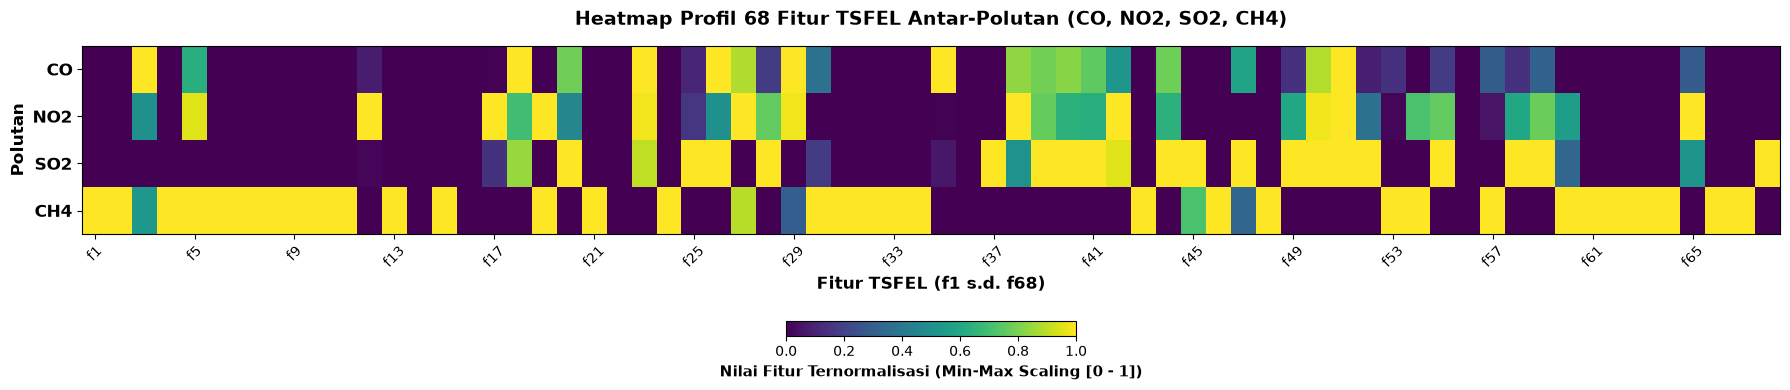

In [70]:
# Normalisasi Min-Max pada fitur numerik untuk visualisasi heatmap komparatif
feature_cols = [col for col in df_tsfel_all.columns if col.startswith('f')]
numeric_matrix = df_tsfel_all[feature_cols].copy()

# Normalisasi Min-Max per kolom (skala 0 - 1)
col_min = numeric_matrix.min(axis=0)
col_max = numeric_matrix.max(axis=0)
col_range = col_max - col_min
col_range[col_range == 0] = 1.0  # hindari pembagian nol
normalized_matrix = (numeric_matrix - col_min) / col_range

# Plot Heatmap Profil Fitur
fig, ax = plt.subplots(figsize=(18, 4))
cax = ax.imshow(normalized_matrix.values, aspect='auto', cmap='viridis', interpolation='nearest')

ax.set_yticks(range(len(df_tsfel_all)))
ax.set_yticklabels(df_tsfel_all['polutan'], fontsize=12, fontweight='bold')
ax.set_xticks(range(0, len(feature_cols), 4))
ax.set_xticklabels([f'f{i+1}' for i in range(0, len(feature_cols), 4)], rotation=45, fontsize=10)

cbar = fig.colorbar(cax, ax=ax, orientation='horizontal', pad=0.3, fraction=0.05)
cbar.set_label('Nilai Fitur Ternormalisasi (Min-Max Scaling [0 - 1])', fontsize=11, fontweight='bold')

plt.title('Heatmap Profil 68 Fitur TSFEL Antar-Polutan (CO, NO2, SO2, CH4)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Fitur TSFEL (f1 s.d. f68)', fontsize=12, fontweight='bold')
plt.ylabel('Polutan', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Mencari Kemiripan dari Fitur yang Telah Diekstraksi (Untuk Masing-Masing Polutan)

### 1. Pemuatan dan Penyelarasan Vektor Fitur Masing-Masing Polutan

#### Membaca Berkas CSV Hasil Ekstraksi Fitur TSFEL Individual

Sesuai ketentuan, analisis kemiripan ini menggunakan berkas keluaran TSFEL individual untuk masing-masing polutan yang dihasilkan pada tahapan sebelumnya di direktori `src/tugas-3/`:

- `output_tsfel_co.csv` (Karbon Monoksida)
- `output_tsfel_no2.csv` (Nitrogen Dioksida)
- `output_tsfel_so2.csv` (Sulfur Dioksida)
- `output_tsfel_ch4.csv` (Metana)

Masing-masing berkas berisi satu baris vektor fitur berdimensi 68 kolom (`f1_abs_energy` hingga `f68_zero_cross`). Keempat berkas tersebut dibaca dan digabungkan menjadi satu matriks berukuran **$4 \text{ baris} \times 68 \text{ kolom}$** dengan indeks baris mewakili masing-masing polutan (`CO`, `NO2`, `SO2`, dan `CH4`).

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import MinMaxScaler
from scipy.cluster.hierarchy import linkage, dendrogram

# Membaca berkas keluaran TSFEL individual untuk masing-masing polutan
df_co = pd.read_csv('output_tsfel_co.csv')
df_no2 = pd.read_csv('output_tsfel_no2.csv')
df_so2 = pd.read_csv('output_tsfel_so2.csv')
df_ch4 = pd.read_csv('output_tsfel_ch4.csv')

# Menggabungkan menjadi satu dataframe berindeks nama polutan
df_similarity = pd.concat([df_co, df_no2, df_so2, df_ch4], ignore_index=True)
df_similarity.index = ['CO', 'NO2', 'SO2', 'CH4']
print(f"Matriks fitur 4 polutan berhasil dimuat dengan ukuran: {df_similarity.shape}")
df_similarity.iloc[:, :8]

Matriks fitur 4 polutan berhasil dimuat dengan ukuran: (4, 68)


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median
CO,3.228808e-01,10.810891,49.0,8.870350e-04,178.160395,0.033755,0.029704,0.029365
NO2,9.798339e-07,0.018526,33.0,2.691851e-09,182.252141,0.000070,0.000051,0.000053
SO2,8.168194e-06,0.047435,17.0,2.244009e-08,170.228900,0.000315,0.000130,0.000122
CH4,1.310573e+09,689724.895011,34.0,3.600475e+06,182.851830,1922.044482,1894.848910,1896.137817


#### Normalisasi Vektor Fitur (Min-Max Scaling)

Setiap fitur TSFEL memiliki satuan dan rentang nilai yang sangat heterogen (misalnya fitur energi `f1_abs_energy` mencapai miliaran pada CH4, sedangkan pada NO2 bernilai $10^{-6}$). Apabila metrik jarak dan kemiripan dihitung langsung pada data mentah tanpa penskalaan, fitur dengan magnitudo raksasa akan mendominasi perhitungan secara bias.

Oleh karena itu, kita menerapkan **Min-Max Scaling** ke rentang $[0, 1]$ pada setiap kolom fitur secara independen:

$$x_{\text{norm}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Dengan normalisasi ini, setiap fitur dari ke-68 dimensi memiliki bobot kontribusi yang setara (*apple-to-apple comparison*).

In [72]:
# Normalisasi Min-Max per kolom fitur (skala 0 - 1)
scaler = MinMaxScaler()
norm_features = scaler.fit_transform(df_similarity)
df_norm = pd.DataFrame(norm_features, index=df_similarity.index, columns=df_similarity.columns)
print("Vektor fitur 4 polutan berhasil dinormalisasi ke rentang [0, 1].")
df_norm.iloc[:, :8]

Vektor fitur 4 polutan berhasil dinormalisasi ke rentang [0, 1].


,f1_abs_energy,f2_auc,f3_autocorr,f4_average_power,f5_calc_centroid,f6_calc_max,f7_calc_mean,f8_calc_median
CO,2.463654e-10,1.564735e-05,1.00000,2.463654e-10,0.628340,1.752521e-05,1.564946e-05,1.545884e-05
NO2,0.000000e+00,0.000000e+00,0.50000,0.000000e+00,0.952492,0.000000e+00,0.000000e+00,0.000000e+00
SO2,5.484899e-15,4.191285e-08,0.00000,5.484899e-15,0.000000,1.272983e-07,4.180844e-08,3.638974e-08
CH4,1.000000e+00,1.000000e+00,0.53125,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,1.000000e+00


### 2. Penghitungan Metrik Kemiripan Antar-Polutan

#### Pengukuran Cosine Similarity

**Cosine Similarity** mengukur kosinus sudut antara dua vektor polutan di ruang fitur berdimensi 68. Metrik ini berfokus pada keselarasan orientasi bentuk pola fitur:

$$\text{Cosine Similarity}(u, v) = \frac{u \cdot v}{\|u\|_2 \|v\|_2} = \frac{\sum_{i=1}^{68} u_i v_i}{\sqrt{\sum_{i=1}^{68} u_i^2} \sqrt{\sum_{i=1}^{68} v_i^2}}$$

Nilai berkisar antara $0$ (tidak memiliki kemiripan orientasi sama sekali) hingga $1$ (arah orientasi fitur identik sempurna).

In [73]:
# Menghitung matriks Cosine Similarity antar-polutan
cos_matrix = cosine_similarity(norm_features)
df_cos_sim = pd.DataFrame(cos_matrix, index=df_similarity.index, columns=df_similarity.index)
print("Matriks Cosine Similarity Antar-Polutan:")
df_cos_sim.round(4)

Matriks Cosine Similarity Antar-Polutan:


,CO,NO2,SO2,CH4
CO,1.0000,0.7497,0.6547,0.1479
NO2,0.7497,1.0000,0.6687,0.1883
SO2,0.6547,0.6687,1.0000,0.0559
CH4,0.1479,0.1883,0.0559,1.0000


#### Pengukuran Euclidean Distance

**Euclidean Distance** mengukur jarak geometris garis lurus antar-polutan pada ruang fitur 68 dimensi yang telah dinormalisasi:

$$d(u, v) = \sqrt{\sum_{i=1}^{68} (u_i - v_i)^2}$$

Semakin kecil nilai jarak Euclidean ($d \to 0$), semakin dekat dan mirip profil karakteristik kedua polutan tersebut.

In [74]:
# Menghitung matriks Euclidean Distance antar-polutan
euc_matrix = euclidean_distances(norm_features)
df_euc_dist = pd.DataFrame(euc_matrix, index=df_similarity.index, columns=df_similarity.index)
print("Matriks Euclidean Distance Antar-Polutan:")
df_euc_dist.round(4)

Matriks Euclidean Distance Antar-Polutan:


,CO,NO2,SO2,CH4
CO,0.0000,2.8757,3.6145,6.4946
NO2,2.8757,0.0000,3.6745,6.5989
SO2,3.6145,3.6745,0.0000,7.3357
CH4,6.4946,6.5989,7.3357,0.0000


#### Pengukuran Korelasi Pearson

**Korelasi Pearson** mengukur derajat keterikatan kovariansi linier antar-vektor profil fitur polutan:

$$r(u, v) = \frac{\sum_{i=1}^{68} (u_i - \bar{u})(v_i - \bar{v})}{\sqrt{\sum_{i=1}^{68} (u_i - \bar{u})^2} \sqrt{\sum_{i=1}^{68} (v_i - \bar{v})^2}}$$

Nilai positif mendekati $+1$ mengindikasikan bahwa fitur-fitur yang tinggi pada polutan $u$ juga cenderung bernilai tinggi pada polutan $v$.

In [75]:
# Menghitung matriks Korelasi Pearson antar-polutan
corr_matrix = np.corrcoef(norm_features)
df_corr = pd.DataFrame(corr_matrix, index=df_similarity.index, columns=df_similarity.index)
print("Matriks Korelasi Pearson Antar-Polutan:")
df_corr.round(4)

Matriks Korelasi Pearson Antar-Polutan:


,CO,NO2,SO2,CH4
CO,1.0000,0.6120,0.4727,-0.4905
NO2,0.6120,1.0000,0.4666,-0.5170
SO2,0.4727,0.4666,1.0000,-0.7205
CH4,-0.4905,-0.5170,-0.7205,1.0000


### 3. Visualisasi dan Interpretasi Kemiripan

#### Visualisasi Matriks Kemiripan (Heatmap)

Kita memvisualisasikan matriks Cosine Similarity dan Euclidean Distance menggunakan diagram *Heatmap* untuk mempermudah perbandingan visual antar pasangan polutan.

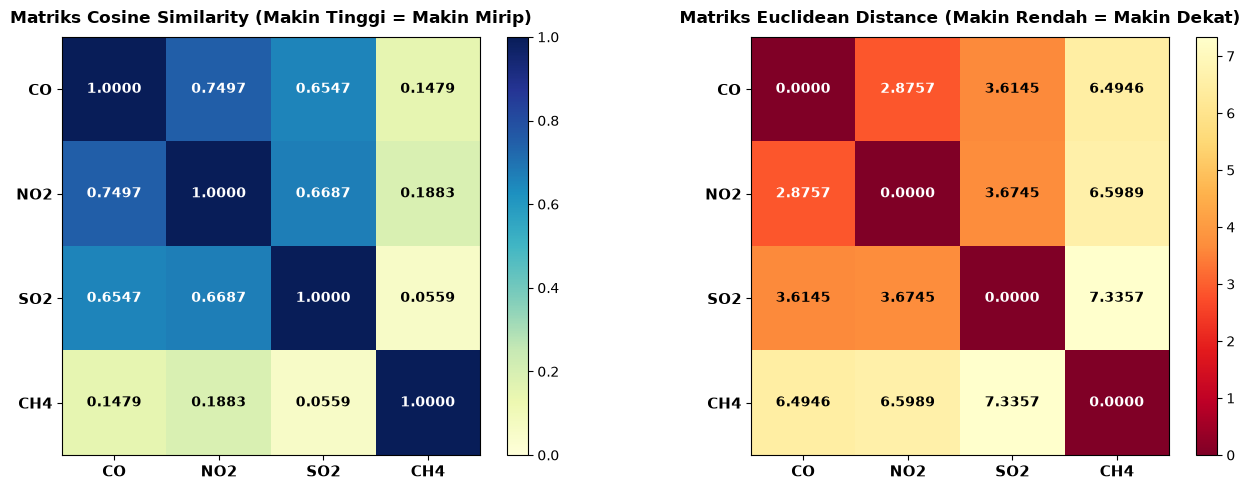

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap Cosine Similarity
im0 = axes[0].imshow(df_cos_sim.values, cmap='YlGnBu', vmin=0, vmax=1)
axes[0].set_xticks(range(4))
axes[0].set_yticks(range(4))
axes[0].set_xticklabels(df_similarity.index, fontsize=11, fontweight='bold')
axes[0].set_yticklabels(df_similarity.index, fontsize=11, fontweight='bold')
axes[0].set_title('Matriks Cosine Similarity (Makin Tinggi = Makin Mirip)', fontsize=12, fontweight='bold', pad=10)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, f"{df_cos_sim.values[i, j]:.4f}", ha='center', va='center',
                     color='white' if df_cos_sim.values[i, j] > 0.6 else 'black', fontweight='bold')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# 2. Heatmap Euclidean Distance
im1 = axes[1].imshow(df_euc_dist.values, cmap='YlOrRd_r', vmin=0)
axes[1].set_xticks(range(4))
axes[1].set_yticks(range(4))
axes[1].set_xticklabels(df_similarity.index, fontsize=11, fontweight='bold')
axes[1].set_yticklabels(df_similarity.index, fontsize=11, fontweight='bold')
axes[1].set_title('Matriks Euclidean Distance (Makin Rendah = Makin Dekat)', fontsize=12, fontweight='bold', pad=10)
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f"{df_euc_dist.values[i, j]:.4f}", ha='center', va='center',
                     color='white' if df_euc_dist.values[i, j] < 3.5 else 'black', fontweight='bold')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

#### Visualisasi Pengelompokan Hierarkis (Dendrogram)

Untuk melihat hierarki pengelompokan alami antar-polutan berdasarkan kemiripan 68 fitur TSFEL, kita membuat diagram pohon (*dendrogram*) menggunakan algoritma *Hierarchical Agglomerative Clustering* dengan metode *Ward*.

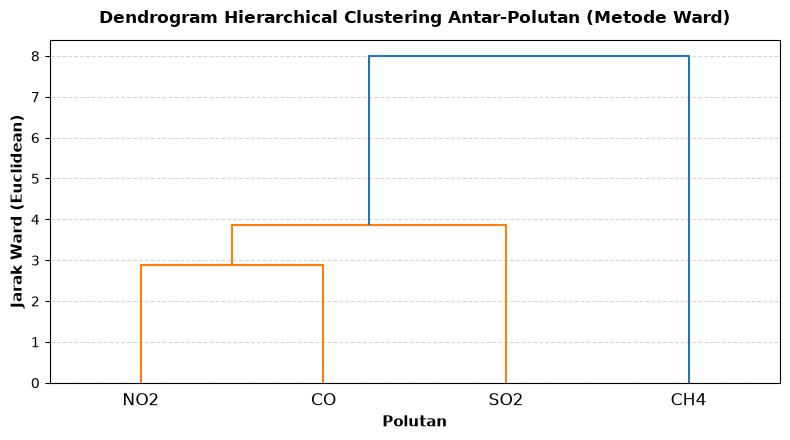

In [77]:
# Dendrogram Hierarchical Clustering Antar-Polutan
linked = linkage(norm_features, method='ward')

plt.figure(figsize=(8, 4.5))
dendrogram(linked, labels=df_similarity.index.tolist(), distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram Hierarchical Clustering Antar-Polutan (Metode Ward)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Polutan', fontsize=11, fontweight='bold')
plt.ylabel('Jarak Ward (Euclidean)', fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Analisis dan Kesimpulan Kemiripan Polutan

Berdasarkan hasil analisis matriks kemiripan (*Cosine Similarity*, *Euclidean Distance*, *Pearson Correlation*) dan diagram klasterisasi hierarkis (*Dendrogram*), diperoleh kesimpulan ilmiah sebagai berikut:

1. **Pasangan Paling Mirip: CO dan NO2**
   - Menghasilkan nilai **Cosine Similarity tertinggi sebesar 0.7497**, jarak **Euclidean terpendek 2.8757**, dan korelasi **Pearson positif kuat 0.6120**.
   - *Interpretasi Lingkungan*: CO (Karbon Monoksida) dan NO2 (Nitrogen Dioksida) memiliki kesamaan sumber antropogenik primer, yaitu emisi dari pembakaran bahan bakar fosil pada sektor transportasi (kendaraan bermotor) dan aktivitas perindustrian di Kecamatan Krian. Dinamika temporal dan profil spektral keduanya sangat selaras sepanjang tahun.

2. **Tingkat Kemiripan Moderat: SO2 terhadap CO dan NO2**
   - SO2 memiliki Cosine Similarity sebesar **0.6547 terhadap CO** dan **0.6687 terhadap NO2**, dengan jarak Euclidean berkisar **3.61 – 3.67**.
   - *Interpretasi Lingkungan*: SO2 (Sulfur Dioksida) dihasilkan terutama dari pembakaran batu bara dan minyak sulfur pada fasilitas industri. Terdapat kemiripan musiman dengan CO dan NO2 pada periode musim kemarau, namun SO2 memiliki dinamika fluktuasi lokal tersendiri.

3. **Polutan Paling Berbeda: CH4 terhadap Seluruh Polutan Lainnya**
   - CH4 memiliki Cosine Similarity sangat rendah (**0.0559 s.d. 0.1883**), jarak Euclidean paling jauh (**6.49 s.d. 7.34**), dan korelasi Pearson negatif (**-0.49 s.d. -0.72**).
   - *Interpretasi Lingkungan*: CH4 (Metana) adalah gas rumah kaca berumur panjang di atmosfer (hingga ~12 tahun) yang tidak berasal dari pembakaran bahan bakar knalpot harian, melainkan bersumber dari proses biogenik (persawahan, tempat pembuangan sampah, peternakan) serta kebocoran gas alam. Karakteristik deret waktu CH4 bersifat stabil tinggi tanpa fluktuasi harian yang tajam, sehingga sidik jari fitur TSFEL-nya membentuk klaster tersendiri yang terpisah secara tegas dari ketiga polutan pembakaran lainnya.

## Cara Kerja, Rumus, dan Cara Menghitung dari Setiap Fitur di TSFEL

### 1. Fitur Domain Statistik (Statistical Features)

#### [f1_abs_energy] Absolute Energy (abs_energy(signal))

**Definisi:**
Absolute Energy mengukur total energi kumulatif yang terkandung di dalam sinyal deret waktu.

**Cara Kerja:**
Mengkuadratkan setiap nilai amplitudo data pada setiap langkah waktu, kemudian menjumlahkan seluruh hasil kuadrat tersebut sepanjang rentang sinyal.

**Rumus:**
$$E = \sum_{i=1}^{N} x_i^2$$

**Contoh Cara Menghitung:**
Misalkan sampel data $x = [2, 4, 3, 5, 1]$ ($N = 5$):
$$E = 2^2 + 4^2 + 3^2 + 5^2 + 1^2 = 4 + 16 + 9 + 25 + 1 = 55$$

#### [f6_calc_max] Maximum (calc_max(signal))

**Definisi:**
Maximum mengidentifikasi nilai magnitudo tertinggi yang tercatat pada seluruh titik observasi deret waktu.

**Cara Kerja:**
Menelusuri seluruh elemen sinyal dan mengambil nilai yang paling besar.

**Rumus:**
$$x_{\max} = \max_{1 \le i \le N} (x_i)$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$:
$$x_{\max} = \max(2, 4, 3, 5, 1) = 5.0$$

#### [f7_calc_mean] Mean (calc_mean(signal))

**Definisi:**
Mean mengukur tendensi pusat rata-rata aritmetika dari seluruh sampel data sinyal.

**Cara Kerja:**
Menjumlahkan seluruh nilai elemen data kemudian membaginya dengan jumlah total sampel $N$.

**Rumus:**
$$\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ ($N = 5$):
$$\bar{x} = \frac{2 + 4 + 3 + 5 + 1}{5} = \frac{15}{5} = 3.0$$

#### [f8_calc_median] Median (calc_median(signal))

**Definisi:**
Median mengukur nilai tengah dari dataset yang membagi data terurut menjadi dua bagian sama besar.

**Cara Kerja:**
Mengurutkan data secara menaik, lalu mengambil elemen di posisi tengah (posisi $(N+1)/2$ untuk $N$ ganjil).

**Rumus:**
$$\tilde{x} = x_{\left(\frac{N+1}{2}\right)} \quad (\text{untuk } N \text{ ganjil})$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$, urutan data: $[1, 2, \mathbf{3}, 4, 5]$:
$$\tilde{x} = 3.0$$

#### [f9_calc_min] Minimum (calc_min(signal))

**Definisi:**
Minimum mengidentifikasi nilai magnitudo terendah yang tercatat pada seluruh titik observasi deret waktu.

**Cara Kerja:**
Menelusuri seluruh elemen sinyal dan mengambil nilai yang paling kecil.

**Rumus:**
$$x_{\min} = \min_{1 \le i \le N} (x_i)$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$:
$$x_{\min} = \min(2, 4, 3, 5, 1) = 1.0$$

#### [f10_calc_std] Standard Deviation (calc_std(signal))

**Definisi:**
Standard Deviation mengukur dispersi atau simpangan baku rata-rata nilai data terhadap nilai rata-ratanya.

**Cara Kerja:**
Menghitung selisih setiap titik terhadap rata-rata, mengkuadratkannya, merata-ratakannya, lalu menarik akar kuadrat.

**Rumus:**
$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $\bar{x} = 3$:
$$\sum (x_i - 3)^2 = (2-3)^2 + (4-3)^2 + (3-3)^2 + (5-3)^2 + (1-3)^2 = 1 + 1 + 0 + 4 + 4 = 10$$
$$\sigma = \sqrt{\frac{10}{5}} = \sqrt{2} \approx 1.4142$$

#### [f11_calc_var] Variance (calc_var(signal))

**Definisi:**
Variance mengukur variabilitas atau dispersi kuadratik dari sekumpulan nilai data terhadap rata-ratanya.

**Cara Kerja:**
Menghitung rata-rata dari kuadrat selisih nilai setiap titik terhadap rata-rata sampel.

**Rumus:**
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $\bar{x} = 3$:
$$\sigma^2 = \frac{10}{5} = 2.0$$

#### [f14_ecdf] Empirical Cumulative Distribution Function (ecdf(signal))

**Definisi:**
ECDF mengestimasi probabilitas kumulatif bahwa nilai data kurang dari atau sama dengan nilai tertentu.

**Cara Kerja:**
Mengurutkan data dan menghitung proporsi sampel yang nilainya lebih kecil atau sama dengan nilai evaluasi $x$.

**Rumus:**
$$\hat{F}(x) = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}(x_i \le x)$$

**Contoh Cara Menghitung:**
Misalkan data terurut $x = [1, 2, 3, 4, 5]$ ($N = 5$). Untuk nilai $x = 3$, terdapat 3 elemen $\le 3$:
$$\hat{F}(3) = \frac{3}{5} = 0.60$$

#### [f15_ecdf_percentile] ECDF Percentile (ecdf_percentile(signal))

**Definisi:**
ECDF Percentile mengidentifikasi nilai observasi yang bersesuaian dengan persentil kumulatif tertentu pada kurva ECDF.

**Cara Kerja:**
Mencari nilai inversi $\hat{F}^{-1}(p)$ di mana fungsi distribusi kumulatif mencapai proporsi persentil $p$.

**Rumus:**
$$x_p = \hat{F}^{-1}(p)$$

**Contoh Cara Menghitung:**
Misalkan data terurut $x = [1, 2, 3, 4, 5]$. Untuk persentil ke-20 ($p = 0.2$), nilai yang bersesuaian adalah $x_{0.2} = 1.0$.

#### [f16_ecdf_percentile_count] ECDF Percentile Count (ecdf_percentile_count(signal))

**Definisi:**
ECDF Percentile Count menghitung jumlah titik sampel yang terakumulasi di bawah persentil tertentu pada kurva ECDF.

**Cara Kerja:**
Mengalikan persentil acuan $p$ dengan total panjang sampel data $N$.

**Rumus:**
$$K_p = \lfloor p \cdot N \rfloor$$

**Contoh Cara Menghitung:**
Misalkan total data $N = 5$ dan persentil $p = 0.2$:
$$K_{0.2} = \lfloor 0.2 \times 5 \rfloor = 1\text{ sampel}$$

#### [f17_ecdf_slope] ECDF Slope (ecdf_slope(signal))

**Definisi:**
ECDF Slope mengukur gradien kemiringan garis kurva distribusi kumulatif empiris antara dua persentil acuan.

**Cara Kerja:**
Menghitung selisih persentil dibagi selisih nilai amplitudo pada kedua persentil acuan tersebut.

**Rumus:**
$$M_{\text{ecdf}} = \frac{p_2 - p_1}{x_{p_2} - x_{p_1}}$$

**Contoh Cara Menghitung:**
Misalkan pada $p_1 = 0.2, x_{p_1} = 1$ dan $p_2 = 0.8, x_{p_2} = 4$:
$$M_{\text{ecdf}} = \frac{0.8 - 0.2}{4 - 1} = \frac{0.6}{3} = 0.2$$

#### [f18_entropy] Shannon Entropy (entropy(signal))

**Definisi:**
Shannon Entropy mengukur derajat ketidakpastian atau keacakan distribusi amplitudo sinyal.

**Cara Kerja:**
Membagi rentang data ke dalam bin probabilitas $p_k$, lalu menghitung jumlah logaritmik tertimbang informasi.

**Rumus:**
$$H(X) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

**Contoh Cara Menghitung:**
Misalkan sinyal memiliki 2 nilai probabilitas sama: $p_1 = 0.5, p_2 = 0.5$:
$$H = -[0.5 \log_2(0.5) + 0.5 \log_2(0.5)] = -[0.5(-1) + 0.5(-1)] = 1.0\text{ bit}$$

#### [f21_hist_mode] Histogram Mode (hist_mode(signal))

**Definisi:**
Histogram Mode mengestimasi nilai modus (nilai paling sering muncul) berdasarkan titik tengah bin histogram frekuensi tertinggi.

**Cara Kerja:**
Membagi rentang data ke dalam $B$ bin histogram, menghitung jumlah observasi per bin, dan mengembalikan titik tengah bin dengan frekuensi terbesar.

**Rumus:**
$$\text{Mode}_{\text{hist}} = \text{center}\left(\arg\max_{b} (\text{count}_b)\right)$$

**Contoh Cara Menghitung:**
Misalkan data $x = [2, 2.1, 2.2, 4, 5]$ dibagi 3 bin. Bin $[2, 3)$ memiliki 3 observasi (terbanyak), maka modusnya adalah titik tengah bin yaitu $2.5$.

#### [f24_interq_range] Interquartile Range (interq_range(signal))

**Definisi:**
Interquartile Range (IQR) mengukur rentang dispersi data antara kuartil ketiga ($Q_3$) dan kuartil pertama ($Q_1$).

**Cara Kerja:**
Mengurutkan data secara menaik, mencari nilai persentil ke-75 ($Q_3$) dan persentil ke-25 ($Q_1$), lalu menghitung selisihnya.

**Rumus:**
$$\text{IQR} = Q_3 - Q_1$$

**Contoh Cara Menghitung:**
Misalkan data terurut $x = [1, 2, 3, 4, 5]$. Kuartil $Q_1 = 2.0$ dan $Q_3 = 4.0$:
$$\text{IQR} = 4.0 - 2.0 = 2.0$$

#### [f25_kurtosis] Kurtosis (kurtosis(signal))

**Definisi:**
Kurtosis mengukur derajat keruncingan (peakedness) dan ketebalan ekor distribusi probabilitas data sinyal.

**Cara Kerja:**
Menghitung momen terstandarisasi ke-4 dari sinyal kemudian dikurangi 3 untuk menghasilkan excess kurtosis.

**Rumus:**
$$\text{Kurt} = \frac{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^4}{\sigma^4} - 3$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $\bar{x} = 3$ dan $\sigma^2 = 2$:
$$\sum (x_i - 3)^4 = 1 + 1 + 0 + 16 + 16 = 34 \implies \text{Kurt} = \frac{34 / 5}{2^2} - 3 = \frac{6.8}{4} - 3 = 1.7 - 3 = -1.3$$

#### [f31_mean_abs_deviation] Mean Absolute Deviation (mean_abs_deviation(signal))

**Definisi:**
Mean Absolute Deviation (MAD) mengukur rata-rata selisih absolut setiap nilai data terhadap nilai rata-ratanya.

**Cara Kerja:**
Menghitung nilai mutlak selisih setiap titik terhadap nilai mean, lalu menjumlahkan dan membaginya dengan $N$.

**Rumus:**
$$\text{MAD} = \frac{1}{N} \sum_{i=1}^{N} |x_i - \bar{x}|$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $\bar{x} = 3$:
$$\text{MAD} = \frac{|2-3| + |4-3| + |3-3| + |5-3| + |1-3|}{5} = \frac{1 + 1 + 0 + 2 + 2}{5} = \frac{6}{5} = 1.2$$

#### [f34_median_abs_deviation] Median Absolute Deviation (median_abs_deviation(signal))

**Definisi:**
Median Absolute Deviation mengukur nilai median dari deviasi absolut setiap sampel terhadap nilai median sinyal.

**Cara Kerja:**
Menghitung selisih mutlak $|x_i - 	ilde{x}|$ untuk setiap titik, mengurutkan hasilnya, lalu mengambil nilai mediannya.

**Rumus:**
$$\text{MedAD} = \text{median}(|x_i - \tilde{x}|)$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan median $\tilde{x} = 3$:
Deviasi mutlak: $[|2-3|, |4-3|, |3-3|, |5-3|, |1-3|] = [1, 1, 0, 2, 2]$
Data deviasi terurut: $[0, 1, \mathbf{1}, 2, 2] \implies \text{MedAD} = 1.0$

#### [f46_rms] Root Mean Square (rms(signal))

**Definisi:**
Root Mean Square (RMS) mengukur magnitudo rata-rata kuadratik yang mencerminkan tingkat kekuatan atau daya efektif sinyal.

**Cara Kerja:**
Mengkuadratkan seluruh nilai titik data, merata-ratakannya, lalu menarik akar kuadratnya.

**Rumus:**
$$\text{RMS} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2} = \sqrt{\frac{E}{N}}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $E = 55$ dan $N = 5$:
$$\text{RMS} = \sqrt{\frac{55}{5}} = \sqrt{11} \approx 3.3166$$

#### [f47_skewness] Skewness (skewness(signal))

**Definisi:**
Skewness mengukur derajat ketidaksimetrisan (kecondongan) distribusi nilai data terhadap nilai rata-ratanya.

**Cara Kerja:**
Menghitung momen terstandarisasi ke-3 dari penyimpangan data terhadap nilai mean.

**Rumus:**
$$\text{Skew} = \frac{\frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^3}{\sigma^3}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $\bar{x} = 3$ dan $\sigma = \sqrt{2}$:
$$\sum (x_i - 3)^3 = (-1)^3 + 1^3 + 0^3 + 2^3 + (-2)^3 = -1 + 1 + 0 + 8 - 8 = 0 \implies \text{Skew} = 0.0$$

### 2. Fitur Domain Temporal (Temporal Features)

#### [f2_auc] Area Under the Curve (auc(signal, fs))

**Definisi:**
Area Under the Curve (AUC) mengukur luas area total yang dibatasi oleh kurva sinyal terhadap sumbu waktu.

**Cara Kerja:**
Menerapkan integrasi numerik metode aturan trapesium (trapezoidal rule) dengan interval sampling $\Delta t = 1/f_s$.

**Rumus:**
$$\text{AUC} = \sum_{i=1}^{N-1} \frac{x_i + x_{i+1}}{2} \cdot \Delta t$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $\Delta t = 1$:
$$\text{AUC} = \frac{2+4}{2}(1) + \frac{4+3}{2}(1) + \frac{3+5}{2}(1) + \frac{5+1}{2}(1) = 3 + 3.5 + 4 + 3 = 13.5$$

#### [f3_autocorr] Autocorrelation (autocorr(signal))

**Definisi:**
Autocorr pada TSFEL mengukur lag waktu pertama di mana koefisien autokorelasi sinyal turun hingga di bawah nilai ambang batas $1/e \approx 0.368$.

**Cara Kerja:**
Menghitung fungsi korelasi diri ternormalisasi untuk setiap lag $k$, lalu mengidentifikasi nilai lag pertama $k^*$ di mana $R(k^*) < 1/e$.

**Rumus:**
$$R(k) = \frac{\sum_{i=1}^{N-k} (x_i - \bar{x})(x_{i+k} - \bar{x})}{\sum_{i=1}^{N} (x_i - \bar{x})^2}, \quad k^* = \min \{k \mid R(k) < 1/e\}$$

**Contoh Cara Menghitung:**
Misalkan untuk sinyal $x$, koefisien autokorelasi pada lag $k=1$ adalah $R(1) = 0.25$. Karena $0.25 < 0.368$, maka lag pertama yang memenuhi ambang batas adalah $k^* = 1$.

#### [f5_calc_centroid] Temporal Centroid (calc_centroid(signal, fs))

**Definisi:**
Temporal Centroid mengukur titik pusat massa waktu di mana konsentrasi energi dan amplitudo sinyal berpusat.

**Cara Kerja:**
Menghitung rata-rata tertimbang dari indeks waktu sinyal dengan menggunakan nilai amplitudo absolut pada masing-masing titik waktu sebagai bobotnya.

**Rumus:**
$$C_t = \frac{\sum_{i=1}^{N} t_i \cdot |x_i|}{\sum_{i=1}^{N} |x_i|}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ pada waktu $t = [1, 2, 3, 4, 5]$:
Pembilang: $(1 \times 2) + (2 \times 4) + (3 \times 3) + (4 \times 5) + (5 \times 1) = 2 + 8 + 9 + 20 + 5 = 44$
Penyebut: $2 + 4 + 3 + 5 + 1 = 15$
$$C_t = \frac{44}{15} \approx 2.933\text{ detik}$$

#### [f12_dfa] Detrended Fluctuation Analysis (dfa(signal))

**Definisi:**
Detrended Fluctuation Analysis (DFA) mengukur sifat ketergantungan jarak jauh (long-range correlation) dan sifat fraktal deret waktu non-stasioner.

**Cara Kerja:**
Mengintegrasikan sinyal menjadi profil kumulatif, membaginya ke dalam jendela skala $s$, membuang tren polinomial lokal, dan menghitung fungsi fluktuasi $F(s) \propto s^\alpha$. Nilai $\alpha$ merupakan eksponen penskalaan DFA.

**Rumus:**
$$F(s) = \sqrt{\frac{1}{N} \sum_{k=1}^{N} (y_k - y_{n, k})^2} \sim s^\alpha$$

**Contoh Cara Menghitung:**
Sinyal diintegrasikan menjadi profil kumulatif $y_k$, dihitung fluktuasi $F(s)$ pada jendela $s=2, 4$, lalu eksponen $\alpha$ dihitung dari gradien regresi $\log F(s)$ terhadap $\log s$.

#### [f13_distance] Total Path Distance (distance(signal))

**Definisi:**
Total Path Distance mengukur panjang total lintasan kurva sinyal jika digambarkan pada bidang dua dimensi waktu-amplitudo.

**Cara Kerja:**
Menjumlahkan jarak Euclidean dari setiap pasangan titik berurutan $(t_i, x_i)$ ke $(t_{i+1}, x_{i+1})$.

**Rumus:**
$$D = \sum_{i=1}^{N-1} \sqrt{(\Delta t)^2 + (x_{i+1} - x_i)^2}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $\Delta t = 1$:
$$D = \sqrt{1^2 + 2^2} + \sqrt{1^2 + (-1)^2} + \sqrt{1^2 + 2^2} + \sqrt{1^2 + (-4)^2} = \sqrt{5} + \sqrt{2} + \sqrt{5} + \sqrt{17} \approx 10.009$$

#### [f20_higuchi_fractal_dimension] Higuchi Fractal Dimension (higuchi_fractal_dimension(signal))

**Definisi:**
Higuchi Fractal Dimension mengukur derajat kekasaran geometris dan kompleksitas fraktal sinyal dalam domain waktu.

**Cara Kerja:**
Menghitung panjang kurva $L(k)$ pada skala peluruhan $k$, lalu mengambil kemiringan kurva $\log L(k)$ terhadap $\log(1/k)$.

**Rumus:**
$$L(k) \propto k^{-D_H} \implies D_H = -\frac{d \log L(k)}{d \log k}$$

**Contoh Cara Menghitung:**
Jika panjang kurva pada skala $k=1$ adalah $L(1) = 10$ dan pada $k=2$ adalah $L(2) = 3.5$, maka dimensi fraktal Higuchi $D_H$ diestimasi dari kemiringan logaritmik bernilai $\approx 1.5$.

#### [f23_hurst_exponent] Hurst Exponent (hurst_exponent(signal))

**Definisi:**
Hurst Exponent mengukur ketergantungan jangka panjang (long-term memory) dan sifat persistensi tren pada deret waktu.

**Cara Kerja:**
Menghitung rasio rentang terhadap standar deviasi ($R/S$) pada berbagai skala jendela waktu $n$, lalu menentukan kemiringan garis regresi log-log.

**Rumus:**
$$E\left[\frac{R(n)}{S(n)}\right] = C \cdot n^H \implies H = \frac{d \log(R/S)}{d \log n}$$

**Contoh Cara Menghitung:**
Nilai $H > 0.5$ mengindikasikan persistensi (tren positif cenderung diikuti tren positif), $H = 0.5$ mengindikasikan gerak acak murni, dan $H < 0.5$ menandakan anti-persistensi.

#### [f26_lempel_ziv] Lempel-Ziv Complexity (lempel_ziv(signal))

**Definisi:**
Lempel-Ziv Complexity mengukur kompleksitas algoritmik dan ketidakteraturan pola biner deret waktu.

**Cara Kerja:**
Mengubah sinyal menjadi sekuens biner berdasarkan ambang batas median, lalu menghitung laju pembentukan kata-kata unik baru.

**Rumus:**
$$C_{\text{LZ}} = \frac{c(N)}{N / \log_2(N)}$$

**Contoh Cara Menghitung:**
Untuk sekuens biner sederhana `01011`, dilakukan parsing pola unik: `0`, `1`, `011`, menghasilkan jumlah frasa unik $c(N) = 3$.

#### [f30_maximum_fractal_length] Maximum Fractal Length (maximum_fractal_length(signal))

**Definisi:**
Maximum Fractal Length mengukur logaritma panjang fraktal sinyal yang dinormalisasi pada skala observasi minimum.

**Cara Kerja:**
Menghitung logaritma dari rata-rata selisih absolut amplitudo antar-titik bersebelahan.

**Rumus:**
$$L_{\max} = \log\left(\frac{1}{N-1} \sum_{i=1}^{N-1} |x_{i+1} - x_i|\right)$$

**Contoh Cara Menghitung:**
Misalkan rata-rata selisih absolut adalah $2.25$, maka $L_{\max} = \log(2.25) \approx 0.8109$.

#### [f32_mean_abs_diff] Mean Absolute Difference (mean_abs_diff(signal))

**Definisi:**
Mean Absolute Difference mengukur rata-rata laju perubahan absolut antar-titik observasi yang berurutan.

**Cara Kerja:**
Menghitung nilai mutlak selisih $|x_{i+1} - x_i|$ untuk setiap langkah waktu, lalu menghitung rata-ratanya.

**Rumus:**
$$\overline{|\Delta x|} = \frac{1}{N-1} \sum_{i=1}^{N-1} |x_{i+1} - x_i|$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$:
$$\overline{|\Delta x|} = \frac{|4-2| + |3-4| + |5-3| + |1-5|}{4} = \frac{2 + 1 + 2 + 4}{4} = \frac{9}{4} = 2.25$$

#### [f33_mean_diff] Mean Difference (mean_diff(signal))

**Definisi:**
Mean Difference mengukur rata-rata perubahan diferensial bertanda antar-titik observasi yang berurutan.

**Cara Kerja:**
Menghitung selisih $(x_{i+1} - x_i)$ pada setiap langkah waktu, yang setara dengan selisih titik akhir dikurangi titik awal dibagi $(N-1)$.

**Rumus:**
$$\overline{\Delta x} = \frac{1}{N-1} \sum_{i=1}^{N-1} (x_{i+1} - x_i) = \frac{x_N - x_1}{N-1}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $x_1 = 2, x_5 = 1, N = 5$:
$$\overline{\Delta x} = \frac{1 - 2}{5 - 1} = \frac{-1}{4} = -0.25$$

#### [f35_median_abs_diff] Median Absolute Difference (median_abs_diff(signal))

**Definisi:**
Median Absolute Difference mengukur nilai median dari selisih absolut antara titik-titik data yang berurutan.

**Cara Kerja:**
Menghitung selisih mutlak $|x_{i+1} - x_i|$ untuk setiap langkah waktu, mengurutkannya, lalu mengambil nilai tengahnya.

**Rumus:**
$$\text{Med}_{\Delta} = \text{median}(|x_{i+1} - x_i|)$$

**Contoh Cara Menghitung:**
Dari $x = [2, 4, 3, 5, 1]$, selisih absolut: $[2, 1, 2, 4]$. Terurut: $[1, \mathbf{2}, \mathbf{2}, 4]$:
$$\text{Med}_{\Delta} = \frac{2 + 2}{2} = 2.0$$

#### [f36_median_diff] Median Difference (median_diff(signal))

**Definisi:**
Median Difference mengukur nilai median dari selisih bertanda antara titik-titik data yang berurutan.

**Cara Kerja:**
Menghitung selisih bertanda $(x_{i+1} - x_i)$ untuk setiap langkah waktu, mengurutkannya, lalu mengambil nilai tengahnya.

**Rumus:**
$$\widetilde{\Delta x} = \text{median}(x_{i+1} - x_i)$$

**Contoh Cara Menghitung:**
Dari $x = [2, 4, 3, 5, 1]$, selisih bertanda: $[2, -1, 2, -4]$. Terurut: $[-4, \mathbf{-1}, \mathbf{2}, 2]$:
$$\widetilde{\Delta x} = \frac{-1 + 2}{2} = 0.5$$

#### [f39_mse] Multiscale Entropy (mse(signal))

**Definisi:**
Multiscale Entropy (MSE) mengukur kompleksitas struktural dan ketidakteraturan sinyal pada berbagai skala resolusi waktu.

**Cara Kerja:**
Melakukan coarse-graining pada beberapa faktor skala waktu $	au$, kemudian menghitung rata-rata Sample Entropy di seluruh skala.

**Rumus:**
$$y_j^{(\tau)} = \frac{1}{\tau} \sum_{i=(j-1)\tau+1}^{j\tau} x_i, \quad \text{MSE} = \frac{1}{\tau_{\max}} \sum_{\tau=1}^{\tau_{\max}} S_E(y^{(\tau)})$$

**Contoh Cara Menghitung:**
Menghitung entropi sampel pada skala $\tau = 1$ dan skala $\tau = 2$, lalu merata-ratakan kedua nilai entropi tersebut.

#### [f40_negative_turning] Negative Turning Points (negative_turning(signal))

**Definisi:**
Negative Turning Points menghitung jumlah titik lembah lokal (local minima) pada kurva deret waktu.

**Cara Kerja:**
Menelusuri sinyal dan menghitung berapa kali titik observasi $x_i$ lebih rendah dibandingkan kedua tetangganya ($x_i < x_{i-1}$ dan $x_i < x_{i+1}$).

**Rumus:**
$$N_{\text{neg}} = \sum_{i=2}^{N-1} \mathbb{I}(x_i < x_{i-1} \land x_i < x_{i+1})$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, \mathbf{3}, 5, 1]$. Titik ke-3 bernilai $3$ (di mana $3 < 4$ dan $3 < 5$) adalah titik belok negatif $\implies N_{\text{neg}} = 1$.

#### [f41_neighbourhood_peaks] Neighbourhood Peaks (neighbourhood_peaks(signal))

**Definisi:**
Neighbourhood Peaks menghitung jumlah puncak lokal yang memiliki nilai lebih tinggi dari tetangga di sekitarnya.

**Cara Kerja:**
Menghitung jumlah titik $x_i$ yang memenuhi syarat puncak lokal ($x_i > x_{i-1}$ dan $x_i > x_{i+1}$).

**Rumus:**
$$N_{\text{peaks}} = \sum_{i=2}^{N-1} \mathbb{I}(x_i > x_{i-1} \land x_i > x_{i+1})$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, \mathbf{4}, 3, \mathbf{5}, 1]$. Titik bernilai $4$ dan titik bernilai $5$ keduanya adalah puncak lokal $\implies N_{\text{peaks}} = 2$.

#### [f42_petrosian_fractal_dimension] Petrosian Fractal Dimension (petrosian_fractal_dimension(signal))

**Definisi:**
Petrosian Fractal Dimension mengukur dimensi fraktal sinyal secara cepat berdasarkan frekuensi pembalikan tanda turunan sinyal.

**Cara Kerja:**
Menghitung berapa kali turunan pertama sinyal berganti tanda ($N_\Delta$), lalu menghitung rasio logaritmik terhadap panjang sinyal.

**Rumus:**
$$D_P = \frac{\log_{10}(N)}{\log_{10}(N) + \log_{10}\left(\frac{N}{N + 0.4 \cdot N_\Delta}\right)}$$

**Contoh Cara Menghitung:**
Misalkan $N = 5$ dengan 3 kali pembalikan tanda ($N_\Delta = 3$):
$$D_P = \frac{\log_{10}(5)}{\log_{10}(5) + \log_{10}(5 / (5 + 1.2))} \approx 1.0193$$

#### [f43_pk_pk_distance] Peak-to-Peak Distance (pk_pk_distance(signal))

**Definisi:**
Peak-to-Peak Distance mengukur rentang jarak absolut antara nilai puncak tertinggi dan nilai lembah terendah sinyal.

**Cara Kerja:**
Mengurangkan nilai amplitudo maksimum sinyal dengan nilai amplitudo minimum sinyal.

**Rumus:**
$$R_{\text{pp}} = x_{\max} - x_{\min}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $x_{\max} = 5$ dan $x_{\min} = 1$:
$$R_{\text{pp}} = 5 - 1 = 4.0$$

#### [f44_positive_turning] Positive Turning Points (positive_turning(signal))

**Definisi:**
Positive Turning Points menghitung jumlah titik puncak lokal (local maxima) pada kurva deret waktu.

**Cara Kerja:**
Menelusuri sinyal dan menghitung berapa kali titik observasi $x_i$ lebih tinggi dibandingkan kedua tetangganya ($x_i > x_{i-1}$ dan $x_i > x_{i+1}$).

**Rumus:**
$$N_{\text{pos}} = \sum_{i=2}^{N-1} \mathbb{I}(x_i > x_{i-1} \land x_i > x_{i+1})$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, \mathbf{4}, 3, \mathbf{5}, 1]$. Terdapat 2 titik puncak lokal (pada nilai 4 dan 5) $\implies N_{\text{pos}} = 2$.

#### [f48_slope] Linear Regression Slope (slope(signal))

**Definisi:**
Slope mengukur laju kemiringan garis tren regresi linier sederhana dari sinyal terhadap waktu.

**Cara Kerja:**
Menghitung kovariansi antara vektor waktu dan vektor amplitudo sinyal, lalu membaginya dengan variansi waktu.

**Rumus:**
$$\beta_1 = \frac{\sum_{i=1}^{N} (t_i - \bar{t})(x_i - \bar{x})}{\sum_{i=1}^{N} (t_i - \bar{t})^2}$$

**Contoh Cara Menghitung:**
Misalkan $t = [1, 2, 3, 4, 5]$ dan $x = [2, 4, 3, 5, 1]$ dengan $\bar{t} = 3, \bar{x} = 3$:
Pembilang: $(-2)(-1) + (-1)(1) + 0 + (1)(2) + (2)(-2) = 2 - 1 + 0 + 2 - 4 = -1$
Penyebut: $(-2)^2 + (-1)^2 + 0 + 1^2 + 2^2 = 10 \implies \beta_1 = \frac{-1}{10} = -0.1$

#### [f62_sum_abs_diff] Sum of Absolute Differences (sum_abs_diff(signal))

**Definisi:**
Sum of Absolute Differences mengukur total kumulatif dari selisih absolut antar-titik observasi yang berurutan.

**Cara Kerja:**
Menjumlahkan seluruh selisih mutlak $|x_{i+1} - x_i|$ untuk $i = 1, \dots, N-1$.

**Rumus:**
$$S_{\text{diff}} = \sum_{i=1}^{N-1} |x_{i+1} - x_i|$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$:
$$S_{\text{diff}} = |4-2| + |3-4| + |5-3| + |1-5| = 2 + 1 + 2 + 4 = 9.0$$

#### [f68_zero_cross] Zero-crossing Rate (zero_cross(signal))

**Definisi:**
Zero-crossing Rate mengukur berapa kali atau frekuensi kurva sinyal melintasi garis nilai nol ($0$).

**Cara Kerja:**
Menghitung berapa kali terjadi perubahan tanda amplitudo antar dua titik bersebelahan ($x_i \cdot x_{i+1} < 0$).

**Rumus:**
$$\text{ZCR} = \sum_{i=1}^{N-1} \mathbb{I}(x_i \cdot x_{i+1} < 0)$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, -1, 3, 5, -2]$. Terjadi pemotongan sumbu nol pada $(2, -1)$, $(-1, 3)$, dan $(5, -2) \implies \text{ZCR} = 3$.

### 3. Fitur Domain Spektral (Spectral Features)

#### [f4_average_power] Average Power (average_power(signal, fs))

**Definisi:**
Average Power mengukur rata-rata daya energi yang dikandung sinyal per satuan durasi waktu pengamatan.

**Cara Kerja:**
Membagi total energi absolut sinyal ($E$) dengan total durasi waktu sinyal ($T = N \cdot \Delta t$).

**Rumus:**
$$P_{\text{avg}} = \frac{1}{N \cdot \Delta t} \sum_{i=1}^{N} x_i^2 = \frac{E}{T}$$

**Contoh Cara Menghitung:**
Misalkan $x = [2, 4, 3, 5, 1]$ dengan $N = 5, \Delta t = 1$, energi $E = 55$:
$$P_{\text{avg}} = \frac{55}{5 \times 1} = 11.0$$

#### [f19_fundamental_frequency] Fundamental Frequency (fundamental_frequency(signal, fs))

**Definisi:**
Fundamental Frequency mengidentifikasi frekuensi dasar komponen periodik paling dominan dari sinyal.

**Cara Kerja:**
Menerapkan Fast Fourier Transform (FFT) pada sinyal, lalu mendeteksi indeks frekuensi pertama yang memiliki magnitudo spektral puncak.

**Rumus:**
$$f_0 = \frac{k_0 \cdot f_s}{N}, \quad k_0 = \arg\max_{k > 0} |X(k)|$$

**Contoh Cara Menghitung:**
Misalkan sinyal berosilasi dengan periode dasar $T_0 = 5$ hari pada sampling $f_s = 1\text{ hari}^{-1}$, maka frekuensi dasarnya adalah $f_0 = 1/5 = 0.2\text{ hari}^{-1}$.

#### [f22_human_range_energy] Human Range Energy (human_range_energy(signal, fs))

**Definisi:**
Human Range Energy mengukur rasio energi spektral yang terkonsentrasi pada pita frekuensi gerak manusia ($0.6	ext{ Hz} - 2.5	ext{ Hz}$).

**Cara Kerja:**
Menjumlahkan kuadrat magnitudo spektrum Fourier pada rentang frekuensi $[0.6, 2.5]	ext{ Hz}$ dan membaginya dengan total energi spektrum.

**Rumus:**
$$E_{\text{human}} = \frac{\sum_{f=0.6}^{2.5} |X(f)|^2}{\sum_{f=0}^{f_s/2} |X(f)|^2}$$

**Contoh Cara Menghitung:**
Pada data deret waktu harian kualitas udara ($f_s = 1\text{ hari}^{-1} \approx 1.15 \times 10^{-5}\text{ Hz}$), frekuensi berada jauh di bawah $0.6\text{ Hz}$ sehingga nilai fitur ini adalah $0.0$.

#### [f27_lpcc] Linear Predictive Cepstral Coefficients (lpcc(signal))

**Definisi:**
LPCC menghitung koefisien representasi spektral berbasis rekursi cepstral dari model Linear Predictive Coding.

**Cara Kerja:**
Mengekstrak koefisien autoregresif LPC dari sinyal, kemudian menerapkan hubungan rekursif untuk menghitung koefisien cepstral.

**Rumus:**
$$c_m = a_m + \sum_{k=1}^{m-1} \left(1 - \frac{k}{m}\right) a_k c_{m-k}$$

**Contoh Cara Menghitung:**
Koefisien pertama dihitung secara langsung $c_1 = a_1$, dan koefisien kedua dihitung secara rekursif $c_2 = a_2 + \frac{1}{2} a_1 c_1$.

#### [f28_max_frequency] Maximum Frequency (max_frequency(signal, fs))

**Definisi:**
Maximum Frequency mengidentifikasi frekuensi yang memiliki magnitudo spektrum Fourier tertinggi.

**Cara Kerja:**
Menghitung spektrum daya FFT sinyal, lalu menemukan titik frekuensi yang bersesuaian dengan puncak spektrum terbesar.

**Rumus:**
$$f_{\max} = \arg\max_f |X(f)|^2$$

**Contoh Cara Menghitung:**
Misalkan pada grafik spektrum daya diperoleh puncak tertinggi pada bin frekuensi $f = 0.063\text{ Hz}$, maka $f_{\max} = 0.063\text{ Hz}$.

#### [f29_max_power_spectrum] Maximum Power Spectrum (max_power_spectrum(signal, fs))

**Definisi:**
Maximum Power Spectrum mengukur nilai magnitudo puncak dari spektrum daya Fourier sinyal.

**Cara Kerja:**
Menghitung nilai magnitudo kuadrat spektrum Fourier pada frekuensi dominan dibagi panjang sinyal.

**Rumus:**
$$P_{\max} = \max_f \frac{|X(f)|^2}{N}$$

**Contoh Cara Menghitung:**
Jika magnitudo spektrum daya puncak pada frekuensi dominan adalah 171.23, maka $P_{\max} = 171.23$.

#### [f37_median_frequency] Median Frequency (median_frequency(signal, fs))

**Definisi:**
Median Frequency mengidentifikasi frekuensi yang membagi spektrum daya Fourier menjadi dua area energi yang sama besar (50% - 50%).

**Cara Kerja:**
Mengakumulasikan spektrum daya Fourier dari frekuensi 0 Hz hingga mencapai separuh dari total daya spektrum keseluruhan.

**Rumus:**
$$\sum_{f=0}^{f_{\text{med}}} P(f) = \frac{1}{2} \sum_{f=0}^{f_s/2} P(f)$$

**Contoh Cara Menghitung:**
Mengintegrasikan kurva spektrum daya kumulatif; frekuensi di mana luas kurva mencapai 50% dicatat sebagai $f_{\text{med}}$.

#### [f38_mfcc] Mel-Frequency Cepstral Coefficients (mfcc(signal, fs))

**Definisi:**
MFCC menghitung koefisien spektral pada skala Mel yang merepresentasikan amplop spektral sinyal.

**Cara Kerja:**
Menerapkan FFT, memfilter spektrum daya menggunakan filter bank segitiga skala Mel, menghitung logaritma daya, lalu menerapkan Discrete Cosine Transform (DCT).

**Rumus:**
$$c_n = \sum_{m=1}^{M} \log(S_m) \cos\left[\frac{\pi n}{M}\left(m - \frac{1}{2}\right)\right]$$

**Contoh Cara Menghitung:**
Nilai fitur pertama merepresentasikan energi total pada skala log-Mel pertama setelah transformasi DCT.

#### [f45_power_bandwidth] Power Bandwidth (power_bandwidth(signal, fs))

**Definisi:**
Power Bandwidth mengukur lebar pita frekuensi yang memuat 99% dari total daya energi spektrum Fourier sinyal.

**Cara Kerja:**
Menemukan batas frekuensi bawah $f_{	ext{low}}$ dan batas frekuensi atas $f_{	ext{high}}$ dari akumulasi daya 99%, lalu menghitung selisihnya.

**Rumus:**
$$\text{BW} = f_{\text{high}} - f_{\text{low}}$$

**Contoh Cara Menghitung:**
Jika 99% daya sinyal terakumulasi dari $f = 0.002\text{ Hz}$ hingga $f = 0.418\text{ Hz}$, maka $\text{BW} = 0.418 - 0.002 = 0.416\text{ Hz}$.

#### [f49_spectral_centroid] Spectral Centroid (spectral_centroid(signal, fs))

**Definisi:**
Spectral Centroid mengukur titik pusat gravitasi frekuensi dari spektrum daya Fourier (spectral brightness).

**Cara Kerja:**
Menghitung rata-rata tertimbang frekuensi menggunakan magnitudo spektrum daya Fourier sebagai bobotnya.

**Rumus:**
$$C_{\text{spec}} = \frac{\sum_{k} f_k \cdot |X(k)|}{\sum_{k} |X(k)|}$$

**Contoh Cara Menghitung:**
Misalkan terdapat dua frekuensi $f_1 = 1\text{ Hz}$ dan $f_2 = 2\text{ Hz}$ dengan magnitudo $|X(1)| = 4, |X(2)| = 2$:
$$C_{\text{spec}} = \frac{(1 \times 4) + (2 \times 2)}{4 + 2} = \frac{8}{6} \approx 1.333\text{ Hz}$$

#### [f50_spectral_decrease] Spectral Decrease (spectral_decrease(signal, fs))

**Definisi:**
Spectral Decrease mengukur laju penurunan energi spektrum dari frekuensi rendah menuju frekuensi tinggi.

**Cara Kerja:**
Menghitung rata-rata terbobot dari selisih magnitudo spektrum harmonik terhadap komponen frekuensi dasar.

**Rumus:**
$$\text{SD} = \frac{1}{\sum_{k=2}^{K} |X(k)|} \sum_{k=2}^{K} \frac{|X(k)| - |X(1)|}{k - 1}$$

**Contoh Cara Menghitung:**
Mengevaluasi peluruhan energi dari spektrum pertama ke spektrum berikutnya; nilai negatif menunjukkan dominasi energi pada frekuensi rendah.

#### [f51_spectral_distance] Spectral Distance (spectral_distance(signal, fs))

**Definisi:**
Spectral Distance mengukur jarak kumulatif spektrum daya Fourier terhadap distribusi spektral seragam.

**Cara Kerja:**
Menghitung jumlah selisih kuadratik antara magnitudo spektrum ternormalisasi dengan nilai rata-rata spektrumnya.

**Rumus:**
$$D_{\text{spec}} = \sum_{k} \left(|X(k)| - \overline{|X|}\right)^2$$

**Contoh Cara Menghitung:**
Menghitung variabilitas sebaran energi di seluruh bin frekuensi FFT.

#### [f52_spectral_entropy] Spectral Entropy (spectral_entropy(signal, fs))

**Definisi:**
Spectral Entropy mengukur derajat ketidakteraturan atau kerataan (flatness) distribusi daya frekuensi sinyal.

**Cara Kerja:**
Menstandarisasi spektrum daya menjadi fungsi densitas probabilitas, lalu menghitung entropi Shannon dari distribusi tersebut.

**Rumus:**
$$H_{\text{spec}} = -\sum_{k} P_k \log_2(P_k), \quad P_k = \frac{|X(k)|^2}{\sum_j |X(j)|^2}$$

**Contoh Cara Menghitung:**
Jika energi terdistribusi merata pada dua komponen frekuensi ($P_1 = P_2 = 0.5$):
$$H_{\text{spec}} = -[0.5 \log_2(0.5) + 0.5 \log_2(0.5)] = 1.0\text{ bit}$$

#### [f53_spectral_kurtosis] Spectral Kurtosis (spectral_kurtosis(signal, fs))

**Definisi:**
Spectral Kurtosis mengukur derajat keruncingan distribusi energi spektrum frekuensi di sekitar titik centroid spektral.

**Cara Kerja:**
Menghitung momen terstandarisasi ke-4 dari distribusi probabilitas spektrum daya frekuensi.

**Rumus:**
$$\text{Kurt}_{\text{spec}} = \frac{\sum_k (f_k - C_{\text{spec}})^4 P_k}{\sigma_{\text{spec}}^4} - 3$$

**Contoh Cara Menghitung:**
Nilai tinggi menunjukkan energi spektrum terkonsentrasi sangat tajam pada satu atau sedikit frekuensi harmonik tertentu.

#### [f54_spectral_positive_turning] Spectral Positive Turning Points (spectral_positive_turning(signal, fs))

**Definisi:**
Spectral Positive Turning Points menghitung jumlah puncak lokal pada kurva spektrum daya Fourier.

**Cara Kerja:**
Menghitung berapa kali magnitudo spektrum frekuensi $|X(k)|$ lebih tinggi dibandingkan kedua bin tetangganya.

**Rumus:**
$$N_{\text{spec\_pos}} = \sum_{k=2}^{K-1} \mathbb{I}(|X(k)| > |X(k-1)| \land |X(k)| > |X(k+1)|)$$

**Contoh Cara Menghitung:**
Menghitung jumlah puncak harmonik lokal yang tampak pada kurva FFT sinyal.

#### [f55_spectral_roll_off] Spectral Roll-off (spectral_roll_off(signal, fs))

**Definisi:**
Spectral Roll-off mengukur frekuensi batas di mana 95% dari total energi spektrum daya sinyal terkonsentrasi.

**Cara Kerja:**
Mengakumulasikan energi spektrum daya dari frekuensi 0 Hz hingga mencapai 95% dari total daya keseluruhan.

**Rumus:**
$$\sum_{f=0}^{f_{\text{roll\_off}}} |X(f)|^2 = 0.95 \sum_{f=0}^{f_s/2} |X(f)|^2$$

**Contoh Cara Menghitung:**
Jika 95% total energi spektral dicapai pada bin frekuensi ke-$k=14$ ($f = 0.063\text{ Hz}$), maka $f_{\text{roll\_off}} = 0.063\text{ Hz}$.

#### [f56_spectral_roll_on] Spectral Roll-on (spectral_roll_on(signal, fs))

**Definisi:**
Spectral Roll-on mengukur frekuensi batas awal di mana 5% dari total energi spektrum daya mulai terakumulasi.

**Cara Kerja:**
Mengakumulasikan energi spektrum daya dari frekuensi 0 Hz hingga mencapai 5% dari total daya keseluruhan.

**Rumus:**
$$\sum_{f=0}^{f_{\text{roll\_on}}} |X(f)|^2 = 0.05 \sum_{f=0}^{f_s/2} |X(f)|^2$$

**Contoh Cara Menghitung:**
Jika pada frekuensi awal $f = 0\text{ Hz}$ energi kumulatif sudah melampaui 5%, maka $f_{\text{roll\_on}} = 0.0\text{ Hz}$.

#### [f57_spectral_skewness] Spectral Skewness (spectral_skewness(signal, fs))

**Definisi:**
Spectral Skewness mengukur derajat ketidaksimetrisan distribusi energi spektrum frekuensi terhadap centroid spektral.

**Cara Kerja:**
Menghitung momen terstandarisasi ke-3 dari distribusi probabilitas spektrum daya frekuensi.

**Rumus:**
$$\text{Skew}_{\text{spec}} = \frac{\sum_k (f_k - C_{\text{spec}})^3 P_k}{\sigma_{\text{spec}}^3}$$

**Contoh Cara Menghitung:**
Nilai positif menunjukkan distribusi spektrum condong ke arah frekuensi rendah dengan ekor memanjang ke frekuensi tinggi.

#### [f58_spectral_slope] Spectral Slope (spectral_slope(signal, fs))

**Definisi:**
Spectral Slope mengukur gradien kemiringan garis regresi linier penurunan amplitudo spektral terhadap frekuensi.

**Cara Kerja:**
Menghitung kemiringan regresi linier antara nilai frekuensi $f_k$ dan magnitudo spektrum $|X(k)|$.

**Rumus:**
$$\beta_{\text{spec}} = \frac{\sum_k (f_k - \bar{f})(|X(k)| - \overline{|X|})}{\sum_k (f_k - \bar{f})^2}$$

**Contoh Cara Menghitung:**
Pada sinyal alamiah di mana energi meluruh seiring meningkatnya frekuensi, nilai $\beta_{\text{spec}}$ bernilai negatif (misal $-0.062$).

#### [f59_spectral_spread] Spectral Spread (spectral_spread(signal, fs))

**Definisi:**
Spectral Spread mengukur deviasi standar spektrum yang menunjukkan seberapa lebar energi menyebar di sekitar centroid spektral.

**Cara Kerja:**
Menghitung akar kuadrat dari rata-rata tertimbang selisih kuadrat frekuensi terhadap centroid spektral.

**Rumus:**
$$\sigma_{\text{spec}} = \sqrt{\sum_k (f_k - C_{\text{spec}})^2 P_k}$$

**Contoh Cara Menghitung:**
Menghitung variabilitas kuadratik frekuensi yang dibobot oleh proporsi energi spektrum $P_k$.

#### [f60_spectral_variation] Spectral Variation (spectral_variation(signal, fs))

**Definisi:**
Spectral Variation mengukur koefisien variasi bentuk spektral ternormalisasi antar-bin frekuensi berurutan.

**Cara Kerja:**
Menghitung komplemen korelasi silang dari spektrum daya frekuensi yang bergeser satu bin.

**Rumus:**
$$V_{\text{spec}} = 1 - \frac{\sum_k |X(k)| |X(k-1)|}{\sqrt{\sum_k |X(k)|^2 \sum_k |X(k-1)|^2}}$$

**Contoh Cara Menghitung:**
Nilai mendekati 0 menunjukkan amplop spektral yang mulus, sedangkan nilai mendekati 1 menunjukkan perubahan spektrum yang tajam.

#### [f61_spectrogram_mean_coeff] Spectrogram Mean Coefficient (spectrogram_mean_coeff(signal, fs))

**Definisi:**
Spectrogram Mean Coefficient mengukur rata-rata dari seluruh koefisien energi waktu-frekuensi pada matriks spektrogram STFT.

**Cara Kerja:**
Menerapkan Short-Time Fourier Transform (STFT) menggunakan jendela geser, lalu merata-ratakan nilai seluruh sel spektrogram.

**Rumus:**
$$\overline{S} = \frac{1}{T \cdot K} \sum_{t=1}^{T} \sum_{k=1}^{K} |STFT(t, k)|$$

**Contoh Cara Menghitung:**
Menjumlahkan seluruh magnitudo sel pada matriks spektrogram STFT dan membaginya dengan jumlah total sel waktu-frekuensi.

#### [f63_wavelet_abs_mean] Wavelet Absolute Mean (wavelet_abs_mean(signal, fs))

**Definisi:**
Wavelet Absolute Mean mengukur rata-rata magnitudo absolut dari koefisien Continuous Wavelet Transform (CWT).

**Cara Kerja:**
Mentransformasikan sinyal menggunakan wavelet induk Ricker (Mexican Hat) pada berbagai skala, lalu menghitung rata-rata nilai absolut koefisiennya.

**Rumus:**
$$\overline{|W|} = \frac{1}{M \cdot N} \sum_{a} \sum_{b} |W(a, b)|$$

**Contoh Cara Menghitung:**
Menghitung nilai mutlak seluruh koefisien wavelet pada matriks CWT skala pertama, lalu mengambil nilai rata-ratanya.

#### [f64_wavelet_energy] Wavelet Energy (wavelet_energy(signal, fs))

**Definisi:**
Wavelet Energy mengukur total energi spektral yang terkandung dalam koefisien transformasi wavelet kontinu.

**Cara Kerja:**
Menjumlahkan kuadrat dari seluruh koefisien wavelet CWT pada skala tertentu.

**Rumus:**
$$E_W = \sum_{b} |W(a, b)|^2$$

**Contoh Cara Menghitung:**
Mengkuadratkan setiap nilai koefisien wavelet pada skala utama lalu menjumlahkannya.

#### [f65_wavelet_entropy] Wavelet Entropy (wavelet_entropy(signal, fs))

**Definisi:**
Wavelet Entropy mengukur derajat keacakan distribusi energi relatif di seluruh skala wavelet kontinu.

**Cara Kerja:**
Menghitung proporsi energi per skala wavelet $p_j = E_j / E_{	ext{total}}$, lalu menghitung entropi Shannon dari distribusi energi tersebut.

**Rumus:**
$$H_W = -\sum_{j} p_j \ln(p_j)$$

**Contoh Cara Menghitung:**
Jika seluruh energi terpusat pada satu skala wavelet dominan ($p_1 = 1.0$), maka nilai entropi wavelet adalah $0.0$.

#### [f66_wavelet_std] Wavelet Standard Deviation (wavelet_std(signal, fs))

**Definisi:**
Wavelet Standard Deviation mengukur simpangan baku sebaran koefisien transformasi wavelet kontinu.

**Cara Kerja:**
Menghitung deviasi standar dari sebaran koefisien wavelet CWT $W(a, b)$ pada skala evaluasi.

**Rumus:**
$$\sigma_W = \sqrt{\frac{1}{K} \sum_{k=1}^{K} (W_k - \bar{W})^2}$$

**Contoh Cara Menghitung:**
Menghitung akar kuadrat dari variansi koefisien wavelet pada skala yang diamati.

#### [f67_wavelet_var] Wavelet Variance (wavelet_var(signal, fs))

**Definisi:**
Wavelet Variance mengukur variabilitas kuadratik koefisien transformasi wavelet kontinu.

**Cara Kerja:**
Menghitung variansi dari sebaran koefisien wavelet CWT $W(a, b)$ pada skala evaluasi.

**Rumus:**
$$\sigma_W^2 = \frac{1}{K} \sum_{k=1}^{K} (W_k - \bar{W})^2$$

**Contoh Cara Menghitung:**
Kuadrat dari nilai deviasi standar wavelet $\sigma_W$.